Expected experiment structure:

```text
experiments/
└── <experiment_type>/
    └── <eval_metric>/
        ├── subject dependent/
        │   ├── models/<MODEL>/<SUBJECT>.pt
        │   └── results/<MODEL>/
        │       ├── config.json
        │       └── <SUBJECT>/
        │           ├── y_true.npy
        │           ├── y_pred.npy
        │           ├── prob.npy
        │           └── conf.npy
        └── subject independent/
            ├── models/<MODEL>/<SUBJECT>.pt
            └── results/<MODEL>/
                ├── config.json
                ├── result.json
                └── <SUBJECT>/
                    ├── y_true.npy
                    ├── y_pred.npy
                    ├── prob.npy
                    └── conf.npy
```

"""

Typical notebook usage:

    from compare_experiments_notebook import *

    EXPERIMENTS_ROOT = Path("/path/to/experiments")
    EXPERIMENT_TYPE = "best_model"
    EVAL_METRIC = "accuracy"

    dependent = analyze_study(
        EXPERIMENTS_ROOT,
        EXPERIMENT_TYPE,
        EVAL_METRIC,
        "subject dependent",
    )

    independent = analyze_study(
        EXPERIMENTS_ROOT,
        EXPERIMENT_TYPE,
        EVAL_METRIC,
        "subject independent",
    )

The functions return pandas DataFrames/dictionaries rather than requiring
command-line arguments. Figures are displayed in Jupyter and can optionally
be saved.

No model training is performed.
"""

In [1]:
from __future__ import annotations

import copy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

try:
    from scipy.stats import wilcoxon

    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False


In [2]:
# ============================================================================
# 1. Configuration / experiment discovery
# ============================================================================

def discover_models(study_dir: Path) -> list[str]:
    """Return model names found under results/."""
    results_dir = study_dir / "results"

    if not results_dir.exists():
        return []

    return sorted(
        p.name
        for p in results_dir.iterdir()
        if p.is_dir()
    )


def discover_subjects(model_results_dir: Path) -> list[str]:
    """Return subject IDs for which y_true.npy and y_pred.npy exist."""
    if not model_results_dir.exists():
        return []

    return sorted(
        p.name
        for p in model_results_dir.iterdir()
        if p.is_dir()
        and (p / "y_true.npy").exists()
        and (p / "y_pred.npy").exists()
    )


def load_config(
    study_dir: Path,
    model: str,
) -> dict | None:
    """Load the model's config.json, if present."""
    path = study_dir / "results" / model / "config.json"

    if not path.exists():
        return None

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def configuration_table(
    study_dir: Path,
) -> pd.DataFrame:
    """
    Create a compact table showing the settings stored in config.json.

    This is useful for verifying that the experiments being compared are
    actually the intended experiments.
    """
    rows = []

    for model in discover_models(study_dir):
        config = load_config(study_dir, model)

        if config is None:
            continue

        settings = config.get("settings", {})
        training = settings.get("training settings", {})
        model_settings = settings.get("model settings", {})

        rows.append({
            "model": model,
            "learning_rate": training.get("learning rate"),
            "weight_decay": training.get("weight decay"),
            "patience": training.get("patience"),
            "epochs": training.get("epoch"),
            "label_smoothing": training.get("label smoothing"),
            "batch_size": training.get("batch size"),
            "accumulation_steps": training.get("accumulation_steps"),
            "activation": model_settings.get("activation_fn"),
            "dropout": model_settings.get("dropout"),
            "output_channels": model_settings.get("output_channels"),
            "output_c_multip": model_settings.get("output_c_multip"),
            "hidden_size": model_settings.get("hidden_size"),
            "num_layers": model_settings.get("num_layers"),
            "windowing_setting_hash": config.get("windowing_setting_hash"),
        })

    return pd.DataFrame(rows)


In [3]:
# ============================================================================
# 2. Loading raw experiment results
# ============================================================================

def load_subject_result(
    results_model_dir: Path,
    subject: str,
) -> dict:
    """Load the raw saved arrays for one subject."""
    subject_dir = results_model_dir / subject

    result = {
        "subject": subject,
        "y_true": np.load(subject_dir / "y_true.npy"),
        "y_pred": np.load(subject_dir / "y_pred.npy"),
        "prob": (
            np.load(subject_dir / "prob.npy")
            if (subject_dir / "prob.npy").exists()
            else None
        ),
        "conf": (
            np.load(subject_dir / "conf.npy")
            if (subject_dir / "conf.npy").exists()
            else None
        ),
    }

    return result


def load_all_results(
    study_dir: Path,
) -> dict[str, dict[str, dict]]:
    """
    Load every model and subject result.

    Returns:
        {
            "CNN": {
                "subject_1": {
                    "y_true": ...,
                    "y_pred": ...,
                    "prob": ...,
                    "conf": ...
                },
                ...
            },
            ...
        }
    """
    all_results = {}

    for model in discover_models(study_dir):
        model_dir = study_dir / "results" / model
        subjects = discover_subjects(model_dir)

        if not subjects:
            continue

        all_results[model] = {}

        for subject in subjects:
            try:
                all_results[model][subject] = load_subject_result(
                    model_dir,
                    subject,
                )
            except Exception as exc:
                print(
                    f"Could not load {model}/{subject}: {exc}"
                )

    return all_results


def available_subjects(
    all_results: dict,
) -> pd.DataFrame:
    """Show which subjects are available for every model."""
    models = sorted(all_results)
    subjects = sorted({
        subject
        for model_results in all_results.values()
        for subject in model_results
    })

    table = []

    for subject in subjects:
        row = {"subject": subject}

        for model in models:
            row[model] = subject in all_results[model]

        table.append(row)

    return pd.DataFrame(table)

In [4]:
# ============================================================================
# 3. Basic classification metrics
# ============================================================================

def calculate_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict:
    """Calculate the main classification metrics."""
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


def calculate_per_class_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    labels: np.ndarray | None = None,
) -> pd.DataFrame:
    """Calculate precision, recall and F1 for every class."""
    if labels is None:
        labels = np.unique(
            np.concatenate([y_true, y_pred])
        )

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=labels,
            zero_division=0,
        )
    )

    return pd.DataFrame({
        "class": labels,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })


def calculate_pooled_metrics(
    all_results: dict,
) -> pd.DataFrame:
    """
    Pool all subjects for each model and calculate overall metrics.

    Important:
    This weights samples equally, so subjects with more test samples
    contribute more to the pooled score.
    """
    rows = []

    for model, subjects in all_results.items():
        if not subjects:
            continue

        y_true = np.concatenate([
            result["y_true"]
            for result in subjects.values()
        ])

        y_pred = np.concatenate([
            result["y_pred"]
            for result in subjects.values()
        ])

        rows.append({
            "model": model,
            **calculate_metrics(y_true, y_pred),
            "n_samples": len(y_true),
            "n_subjects": len(subjects),
        })

    return pd.DataFrame(rows)


def calculate_subject_metrics(
    all_results: dict,
) -> pd.DataFrame:
    """Calculate metrics independently for every subject/model pair."""
    rows = []

    for model, subjects in all_results.items():
        for subject, result in subjects.items():
            rows.append({
                "model": model,
                "subject": subject,
                **calculate_metrics(
                    result["y_true"],
                    result["y_pred"],
                ),
            })

    return pd.DataFrame(rows)


def summarize_subject_metrics(
    subject_metrics: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarize the distribution of subject-level performance.

    This is preferable to relying only on pooled performance when studying
    subject generalization.
    """
    if subject_metrics.empty:
        return pd.DataFrame()

    summary = (
        subject_metrics
        .groupby("model")
        .agg(
            accuracy_mean=("accuracy", "mean"),
            accuracy_std=("accuracy", "std"),
            accuracy_median=("accuracy", "median"),
            accuracy_min=("accuracy", "min"),
            accuracy_max=("accuracy", "max"),
            accuracy_q1=("accuracy", lambda x: x.quantile(0.25)),
            accuracy_q3=("accuracy", lambda x: x.quantile(0.75)),

            macro_f1_mean=("macro_f1", "mean"),
            macro_f1_std=("macro_f1", "std"),
            macro_f1_median=("macro_f1", "median"),

            balanced_accuracy_mean=(
                "balanced_accuracy",
                "mean",
            ),
            balanced_accuracy_std=(
                "balanced_accuracy",
                "std",
            ),
            balanced_accuracy_median=(
                "balanced_accuracy",
                "median",
            ),
        )
        .reset_index()
    )

    return summary


In [5]:
# ============================================================================
# 4. Per-class analysis
# ============================================================================

def get_global_labels(
    all_results: dict,
) -> np.ndarray:
    """Get all class labels occurring in the loaded results."""
    labels = set()

    for model_results in all_results.values():
        for result in model_results.values():
            labels.update(
                np.asarray(result["y_true"]).tolist()
            )
            labels.update(
                np.asarray(result["y_pred"]).tolist()
            )

    return np.array(sorted(labels))


def calculate_pooled_per_class_metrics(
    all_results: dict,
) -> dict[str, pd.DataFrame]:
    """Return a per-class metric table for every model."""
    labels = get_global_labels(all_results)
    output = {}

    for model, subjects in all_results.items():
        y_true = np.concatenate([
            result["y_true"]
            for result in subjects.values()
        ])
        y_pred = np.concatenate([
            result["y_pred"]
            for result in subjects.values()
        ])

        output[model] = calculate_per_class_metrics(
            y_true,
            y_pred,
            labels,
        )

    return output


In [6]:
# ============================================================================
# 5. Confusion matrices
# ============================================================================

def pooled_confusion_matrix(
    result_by_subject: dict,
    normalize: str | None = "true",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Create a pooled confusion matrix for a model.

    normalize='true' makes every row sum to 1 and is generally the most
    interpretable choice for comparing class recognition.
    """
    y_true = np.concatenate([
        result["y_true"]
        for result in result_by_subject.values()
    ])

    y_pred = np.concatenate([
        result["y_pred"]
        for result in result_by_subject.values()
    ])

    labels = np.array(sorted(
        set(y_true.tolist()) | set(y_pred.tolist())
    ))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
        normalize=normalize,
    )

    return cm, labels

In [7]:
# ============================================================================
# 6. Confidence analysis
# ============================================================================

def extract_confidence(
    result: dict,
) -> np.ndarray | None:
    """
    Use saved confidence values.

    If confidence was not saved, derive confidence as the maximum class
    probability when prob.npy is available.
    """
    if result["conf"] is not None:
        return np.asarray(result["conf"]).reshape(-1)

    if result["prob"] is not None:
        prob = np.asarray(result["prob"])

        if prob.ndim == 2:
            return np.max(prob, axis=1)

    return None


def calculate_confidence_metrics(
    result: dict,
) -> dict | None:
    """Compare confidence for correct and incorrect predictions."""
    y_true = np.asarray(result["y_true"])
    y_pred = np.asarray(result["y_pred"])

    confidence = extract_confidence(result)

    if confidence is None:
        return None

    if len(confidence) != len(y_true):
        return None

    correct = y_true == y_pred

    correct_mean = (
        float(np.mean(confidence[correct]))
        if np.any(correct)
        else np.nan
    )

    incorrect_mean = (
        float(np.mean(confidence[~correct]))
        if np.any(~correct)
        else np.nan
    )

    return {
        "mean_confidence": float(np.mean(confidence)),
        "confidence_correct": correct_mean,
        "confidence_incorrect": incorrect_mean,
        "confidence_gap": (
            correct_mean - incorrect_mean
            if not np.isnan(correct_mean)
            and not np.isnan(incorrect_mean)
            else np.nan
        ),
        "accuracy": float(np.mean(correct)),
    }


def calculate_confidence_table(
    all_results: dict,
) -> pd.DataFrame:
    """Create one confidence/calibration row per subject/model."""
    rows = []

    for model, subjects in all_results.items():
        for subject, result in subjects.items():
            metrics = calculate_confidence_metrics(result)

            if metrics is None:
                continue

            rows.append({
                "model": model,
                "subject": subject,
                **metrics,
            })

    return pd.DataFrame(rows)


def calculate_ece(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    prob: np.ndarray,
    n_bins: int = 10,
) -> float:
    """
    Expected Calibration Error.

    Assumes prob contains one probability per class per sample.
    """
    prob = np.asarray(prob)

    if prob.ndim != 2:
        return np.nan

    confidence = np.max(prob, axis=1)
    correct = (
        np.asarray(y_pred) == np.asarray(y_true)
    )

    bins = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for lower, upper in zip(bins[:-1], bins[1:]):
        if upper == 1.0:
            mask = (
                (confidence >= lower)
                & (confidence <= upper)
            )
        else:
            mask = (
                (confidence >= lower)
                & (confidence < upper)
            )

        if not np.any(mask):
            continue

        accuracy = np.mean(correct[mask])
        mean_confidence = np.mean(confidence[mask])
        fraction = np.mean(mask)

        ece += fraction * abs(
            accuracy - mean_confidence
        )

    return float(ece)


def calculate_multiclass_brier(
    y_true: np.ndarray,
    prob: np.ndarray,
) -> float:
    """
    Multiclass Brier score.

    The probability columns must correspond to the class ordering used
    by the training code. If that ordering cannot be verified, treat the
    value as unavailable rather than interpreting it blindly.
    """
    prob = np.asarray(prob)

    if prob.ndim != 2:
        return np.nan

    labels = np.unique(y_true)

    if prob.shape[1] != len(labels):
        return np.nan

    one_hot = np.zeros_like(prob, dtype=float)

    for i, label in enumerate(labels):
        one_hot[:, i] = (
            np.asarray(y_true) == label
        ).astype(float)

    return float(
        np.mean(
            np.sum((prob - one_hot) ** 2, axis=1)
        )
    )


def calculate_calibration_table(
    all_results: dict,
    n_bins: int = 10,
) -> pd.DataFrame:
    """Calculate ECE and Brier score per subject/model."""
    rows = []

    for model, subjects in all_results.items():
        for subject, result in subjects.items():
            if result["prob"] is None:
                continue

            prob = np.asarray(result["prob"])

            if prob.ndim != 2:
                continue

            rows.append({
                "model": model,
                "subject": subject,
                "ece": calculate_ece(
                    result["y_true"],
                    result["y_pred"],
                    prob,
                    n_bins,
                ),
                "brier": calculate_multiclass_brier(
                    result["y_true"],
                    prob,
                ),
            })

    return pd.DataFrame(rows)

In [8]:
# ============================================================================
# 7. Statistical comparisons
# ============================================================================

def paired_model_comparison(
    subject_metrics: pd.DataFrame,
    metric: str = "accuracy",
) -> pd.DataFrame:
    """
    Pairwise Wilcoxon signed-rank tests.

    Only subjects available for both models are used, making this a paired
    comparison.
    """
    if subject_metrics.empty:
        return pd.DataFrame()

    if not SCIPY_AVAILABLE:
        raise ImportError(
            "SciPy is required for Wilcoxon tests. "
            "Install it with: pip install scipy"
        )

    models = sorted(
        subject_metrics["model"].unique()
    )

    rows = []

    for i, model_a in enumerate(models):
        for model_b in models[i + 1:]:
            a = (
                subject_metrics[
                    subject_metrics["model"] == model_a
                ][["subject", metric]]
                .rename(columns={metric: "a"})
            )

            b = (
                subject_metrics[
                    subject_metrics["model"] == model_b
                ][["subject", metric]]
                .rename(columns={metric: "b"})
            )

            paired = a.merge(
                b,
                on="subject",
                how="inner",
            )

            if len(paired) < 2:
                continue

            diff = (
                paired["a"].to_numpy()
                - paired["b"].to_numpy()
            )

            if np.allclose(diff, 0):
                statistic = 0.0
                p_value = 1.0
            else:
                test = wilcoxon(
                    paired["a"],
                    paired["b"],
                    alternative="two-sided",
                )
                statistic = float(test.statistic)
                p_value = float(test.pvalue)

            rows.append({
                "model_a": model_a,
                "model_b": model_b,
                "metric": metric,
                "n_pairs": len(paired),
                "mean_a": paired["a"].mean(),
                "mean_b": paired["b"].mean(),
                "mean_difference": diff.mean(),
                "wilcoxon_statistic": statistic,
                "p_value": p_value,
                "significant_0.05": p_value < 0.05,
            })

    return pd.DataFrame(rows)


def paired_cohen_dz(
    subject_metrics: pd.DataFrame,
    metric: str = "accuracy",
) -> pd.DataFrame:
    """Calculate paired Cohen's dz for every model pair."""
    if subject_metrics.empty:
        return pd.DataFrame()

    models = sorted(
        subject_metrics["model"].unique()
    )

    rows = []

    for i, model_a in enumerate(models):
        for model_b in models[i + 1:]:
            a = (
                subject_metrics[
                    subject_metrics["model"] == model_a
                ][["subject", metric]]
                .rename(columns={metric: "a"})
            )

            b = (
                subject_metrics[
                    subject_metrics["model"] == model_b
                ][["subject", metric]]
                .rename(columns={metric: "b"})
            )

            paired = a.merge(
                b,
                on="subject",
                how="inner",
            )

            if len(paired) < 2:
                continue

            diff = (
                paired["a"].to_numpy()
                - paired["b"].to_numpy()
            )

            sd = np.std(diff, ddof=1)

            effect = (
                np.nan
                if sd == 0
                else np.mean(diff) / sd
            )

            rows.append({
                "model_a": model_a,
                "model_b": model_b,
                "metric": metric,
                "n_pairs": len(diff),
                "cohen_dz": effect,
            })

    return pd.DataFrame(rows)

In [9]:
# ============================================================================
# 8. Model complexity
# ============================================================================

def model_complexity(
    study_dir: Path,
) -> pd.DataFrame:
    """
    Inspect saved .pt files.

    Parameters are counted from the state_dict. This is appropriate for
    comparing architecture size when the .pt files contain state_dicts,
    as in the supplied training code.
    """
    models_dir = study_dir / "models"

    if not models_dir.exists():
        return pd.DataFrame()

    rows = []

    for model_dir in sorted(
        p for p in models_dir.iterdir()
        if p.is_dir()
    ):
        for pt_file in sorted(model_dir.glob("*.pt")):
            try:
                state_dict = torch.load(
                    pt_file,
                    map_location="cpu",
                    weights_only=True,
                )

                parameters = sum(
                    tensor.numel()
                    for tensor in state_dict.values()
                    if torch.is_tensor(tensor)
                )

                rows.append({
                    "model": model_dir.name,
                    "subject": pt_file.stem,
                    "parameters": parameters,
                    "model_size_mb": (
                        pt_file.stat().st_size
                        / (1024 ** 2)
                    ),
                })

            except Exception as exc:
                print(
                    f"Could not inspect {pt_file}: {exc}"
                )

    return pd.DataFrame(rows)


def summarize_model_complexity(
    complexity: pd.DataFrame,
) -> pd.DataFrame:
    """Average model size and parameter count across subjects."""
    if complexity.empty:
        return pd.DataFrame()

    return (
        complexity
        .groupby("model")
        .agg(
            parameters_mean=("parameters", "mean"),
            parameters_std=("parameters", "std"),
            model_size_mb_mean=("model_size_mb", "mean"),
            model_size_mb_std=("model_size_mb", "std"),
        )
        .reset_index()
    )


In [25]:
# ============================================================================
# 9. Plotting helpers
# ============================================================================

def format_subject_id(subject: str) -> str:
    """Shorten subject IDs for plot labels."""
    return str(subject)[:SUBJECT_ID_LENGTH]


def format_class_label(class_id) -> str:
    """Convert numeric class IDs to human-readable labels."""
    try:
        class_id = int(class_id)
    except (TypeError, ValueError):
        return str(class_id)

    return CLASS_NAMES.get(
        class_id,
        f"Class {class_id}",
    )

def save_figure(
    fig,
    path: str | Path | None = None,
):
    """
    Display is handled automatically by Jupyter.

    If path is provided, also save the figure.
    """
    if path is not None:
        path = Path(path)
        path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )
        fig.savefig(
            path,
            dpi=200,
            bbox_inches="tight",
        )

    plt.show()


def plot_overall_metrics(
    pooled_metrics: pd.DataFrame,
    metrics: list[str] | None = None,
    save_dir: str | Path | None = None,
):
    """Plot overall model performance."""
    if pooled_metrics.empty:
        return

    if metrics is None:
        metrics = [
            "accuracy",
            "macro_f1",
            "balanced_accuracy",
            "macro_precision",
            "macro_recall",
        ]

    titles = {
        "accuracy": "Accuracy",
        "macro_f1": "Macro F1",
        "balanced_accuracy": "Balanced Accuracy",
        "macro_precision": "Macro Precision",
        "macro_recall": "Macro Recall",
    }

    for metric in metrics:
        if metric not in pooled_metrics:
            continue

        data = pooled_metrics.sort_values(
            metric,
            ascending=False,
        )

        fig, ax = plt.subplots(figsize=(10, 6))

        ax.bar(
            data["model"],
            data[metric],
        )

        ax.set_title(
            titles.get(metric, metric)
        )
        ax.set_ylabel(
            titles.get(metric, metric)
        )
        ax.set_ylim(0, 1)
        ax.tick_params(
            axis="x",
            rotation=35,
        )

        for i, value in enumerate(data[metric]):
            ax.text(
                i,
                value + 0.015,
                f"{value:.3f}",
                ha="center",
            )

        path = None

        if save_dir is not None:
            path = (
                Path(save_dir)
                / f"overall_{metric}.png"
            )

        save_figure(fig, path)


def plot_subject_variability(
    subject_metrics: pd.DataFrame,
    metric: str = "accuracy",
    save_path: str | Path | None = None,
):
    """Box plot showing variation across subjects."""
    if subject_metrics.empty:
        return

    models = sorted(
        subject_metrics["model"].unique()
    )

    data = [
        subject_metrics[
            subject_metrics["model"] == model
        ][metric].dropna().to_numpy()
        for model in models
    ]

    if not any(len(values) for values in data):
        return

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.boxplot(
        data,
        labels=models,
    )

    ax.set_title(
        f"Per-Subject {metric.replace('_', ' ').title()}"
    )
    ax.set_ylabel(
        metric.replace("_", " ").title()
    )
    ax.set_ylim(0, 1)
    ax.tick_params(
        axis="x",
        rotation=35,
    )

    save_figure(fig, save_path)


def plot_subject_metric_lines(
    subject_metrics: pd.DataFrame,
    metric: str = "accuracy",
    save_path: str | Path | None = None,
):
    """
    Plot every model's performance for every subject.

    Subject IDs are shortened to the first 8 characters for readability.
    The original subject IDs in subject_metrics are not modified.
    """
    if subject_metrics.empty:
        return

    pivot = subject_metrics.pivot(
        index="subject",
        columns="model",
        values=metric,
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(pivot.index))

    for model in pivot.columns:
        ax.plot(
            x,
            pivot[model],
            marker="o",
            label=model,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            format_subject_id(subject)
            for subject in pivot.index
        ],
        rotation=45,
        ha="right",
    )

    ax.set_title(
        f"Per-Subject {metric.replace('_', ' ').title()}"
    )
    ax.set_ylabel(
        metric.replace("_", " ").title()
    )
    ax.set_ylim(0, 1)
    ax.set_xlabel("Subject")
    ax.legend()

    save_figure(fig, save_path)


def plot_confusion_matrix(
    result_by_subject: dict,
    model_name: str,
    normalize: str | None = "true",
    save_path: str | Path | None = None,
):
    """Plot a single model's pooled confusion matrix."""
    cm, labels = pooled_confusion_matrix(
        result_by_subject,
        normalize,
    )

    class_labels = [
        format_class_label(label)
        for label in labels
    ]

    fig, ax = plt.subplots(figsize=(10, 8))

    image = ax.imshow(
        cm,
        interpolation="nearest",
    )

    fig.colorbar(
        image,
        ax=ax,
    )

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=class_labels,
        yticklabels=class_labels,
        xlabel="Predicted class",
        ylabel="True class",
        title=f"{model_name}: Confusion Matrix",
    )

    ax.tick_params(
        axis="x",
        rotation=25,
    )

    threshold = (
        np.nanmax(cm) / 2
        if np.size(cm)
        else 0
    )

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]

            if normalize == "true":
                text = f"{value:.2f}"
            else:
                text = f"{value:.0f}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                color=(
                    "white"
                    if value > threshold
                    else "black"
                ),
            )

    save_figure(fig, save_path)


def plot_all_confusion_matrices(
    all_results: dict,
    save_dir: str | Path | None = None,
):
    """Generate one confusion matrix figure per model."""
    for model, subjects in all_results.items():
        path = None

        if save_dir is not None:
            path = (
                Path(save_dir)
                / f"confusion_{model}.png"
            )

        plot_confusion_matrix(
            subjects,
            model,
            save_path=path,
        )


def plot_per_class_f1(
    per_class_results: dict[str, pd.DataFrame],
    save_path: str | Path | None = None,
):
    """Compare per-class F1 across models."""
    if not per_class_results:
        return

    rows = []

    for model, df in per_class_results.items():
        for _, row in df.iterrows():
            rows.append({
                "model": model,
                "class": row["class"],
                "f1": row["f1"],
            })

    data = pd.DataFrame(rows)

    if data.empty:
        return

    pivot = data.pivot(
        index="class",
        columns="model",
        values="f1",
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    pivot.plot(
        kind="bar",
        ax=ax,
    )

    ax.set_title("Per-Class F1 Comparison")
    ax.set_xlabel("Class")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1)

    ax.set_xticklabels(
        [
            format_class_label(class_id)
            for class_id in pivot.index
        ],
        rotation=20,
        ha="right",
    )

    ax.legend(title="Model")

    save_figure(fig, save_path)


def plot_confidence_correct_incorrect(
    confidence_table: pd.DataFrame,
    save_path: str | Path | None = None,
):
    """Compare confidence on correct vs incorrect predictions."""
    if confidence_table.empty:
        return

    data = (
        confidence_table
        .groupby("model")
        .agg(
            correct=(
                "confidence_correct",
                "mean",
            ),
            incorrect=(
                "confidence_incorrect",
                "mean",
            ),
        )
        .dropna()
    )

    if data.empty:
        return

    x = np.arange(len(data))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.bar(
        x - width / 2,
        data["correct"],
        width,
        label="Correct",
    )

    ax.bar(
        x + width / 2,
        data["incorrect"],
        width,
        label="Incorrect",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        data.index,
        rotation=35,
    )
    ax.set_ylabel("Mean confidence")
    ax.set_ylim(0, 1)
    ax.set_title(
        "Confidence: Correct vs Incorrect Predictions"
    )
    ax.legend()

    save_figure(fig, save_path)


def plot_calibration(
    all_results: dict,
    model_name: str,
    n_bins: int = 10,
    save_path: str | Path | None = None,
):
    """
    Reliability diagram for one model.

    Only use this when prob.npy contains genuine class probabilities.
    """
    if model_name not in all_results:
        return

    confidence_values = []
    correctness_values = []

    for result in all_results[model_name].values():
        if result["prob"] is None:
            continue

        prob = np.asarray(result["prob"])

        if prob.ndim != 2:
            continue

        confidence_values.append(
            np.max(prob, axis=1)
        )

        correctness_values.append(
            (
                result["y_pred"]
                == result["y_true"]
            ).astype(float)
        )

    if not confidence_values:
        print(
            f"No probability data available for {model_name}."
        )
        return

    confidence = np.concatenate(
        confidence_values
    )
    correctness = np.concatenate(
        correctness_values
    )

    bins = np.linspace(
        0,
        1,
        n_bins + 1,
    )

    bin_confidence = []
    bin_accuracy = []

    for lower, upper in zip(
        bins[:-1],
        bins[1:],
    ):
        if upper == 1:
            mask = (
                (confidence >= lower)
                & (confidence <= upper)
            )
        else:
            mask = (
                (confidence >= lower)
                & (confidence < upper)
            )

        if not np.any(mask):
            continue

        bin_confidence.append(
            np.mean(confidence[mask])
        )
        bin_accuracy.append(
            np.mean(correctness[mask])
        )

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    ax.plot(
        bin_confidence,
        bin_accuracy,
        marker="o",
        label=model_name,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted confidence")
    ax.set_ylabel("Observed accuracy")
    ax.set_title(
        f"Reliability Diagram: {model_name}"
    )
    ax.legend()

    save_figure(fig, save_path)


def plot_accuracy_vs_complexity(
    pooled_metrics: pd.DataFrame,
    complexity: pd.DataFrame,
    save_path: str | Path | None = None,
):
    """Show whether more parameters correspond to better accuracy."""
    if pooled_metrics.empty or complexity.empty:
        return

    complexity_summary = summarize_model_complexity(
        complexity
    )

    data = pooled_metrics.merge(
        complexity_summary,
        on="model",
        how="inner",
    )

    if data.empty:
        return

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.scatter(
        data["parameters_mean"],
        data["accuracy"],
    )

    for _, row in data.iterrows():
        ax.annotate(
            row["model"],
            (
                row["parameters_mean"],
                row["accuracy"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
        )

    ax.set_xscale("log")
    ax.set_xlabel("Trainable parameters")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.set_title(
        "Accuracy vs Model Complexity"
    )

    save_figure(fig, save_path)



In [30]:
# ============================================================================
# 10. Subject-dependent vs subject-independent comparison
# ============================================================================

def compare_studies(
    dependent_pooled: pd.DataFrame,
    independent_pooled: pd.DataFrame,
    output_dir: str | Path = "comparison",
) -> pd.DataFrame:
    """
    Compare subject-dependent and subject-independent pooled performance
    and create a PNG visualization.

    The accuracy change is:

        independent - dependent

    Therefore, a negative value means performance decreased for
    subject-independent generalization.

    Returns
    -------
    pd.DataFrame
        Comparison of the two studies.
    """

    if dependent_pooled.empty or independent_pooled.empty:
        return pd.DataFrame()

    dep = dependent_pooled[
        [
            "model",
            "accuracy",
            "macro_f1",
            "balanced_accuracy",
        ]
    ].rename(columns={
        "accuracy": "dependent_accuracy",
        "macro_f1": "dependent_macro_f1",
        "balanced_accuracy": "dependent_balanced_accuracy",
    })

    indep = independent_pooled[
        [
            "model",
            "accuracy",
            "macro_f1",
            "balanced_accuracy",
        ]
    ].rename(columns={
        "accuracy": "independent_accuracy",
        "macro_f1": "independent_macro_f1",
        "balanced_accuracy": "independent_balanced_accuracy",
    })

    comparison = dep.merge(indep, on="model", how="inner")

    comparison["accuracy_change"] = (
        comparison["independent_accuracy"]
        - comparison["dependent_accuracy"]
    )

    comparison["accuracy_drop"] = (
        comparison["dependent_accuracy"]
        - comparison["independent_accuracy"]
    )

    comparison["macro_f1_change"] = (
        comparison["independent_macro_f1"]
        - comparison["dependent_macro_f1"]
    )

    comparison["balanced_accuracy_change"] = (
        comparison["independent_balanced_accuracy"]
        - comparison["dependent_balanced_accuracy"]
    )

    # ---------------------------------------------------------
    # Create output directory
    # ---------------------------------------------------------

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # ---------------------------------------------------------
    # Create accuracy comparison diagram
    # ---------------------------------------------------------

    models = comparison["model"].tolist()

    dependent_accuracy = comparison["dependent_accuracy"].to_numpy()
    independent_accuracy = comparison["independent_accuracy"].to_numpy()

    x = np.arange(len(models))
    width = 0.38

    fig, ax = plt.subplots(figsize=(12, 6))

    bars_dependent = ax.bar(
        x - width / 2,
        dependent_accuracy,
        width,
        label="Subject-dependent",
    )

    bars_independent = ax.bar(
        x + width / 2,
        independent_accuracy,
        width,
        label="Subject-independent",
    )

    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy")
    ax.set_title(
        "Subject-dependent vs. Subject-independent Accuracy"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha="right")

    ax.set_ylim(0, 1)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}")
    )

    ax.legend()

    # Add values above bars
    for bars in [bars_dependent, bars_independent]:
        for bar in bars:
            height = bar.get_height()

            ax.annotate(
                f"{height:.2%}",
                xy=(
                    bar.get_x() + bar.get_width() / 2,
                    height,
                ),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    fig.tight_layout()

    figure_path = output_dir / "dependent_vs_independent_accuracy.png"

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(f"Saved figure to: {figure_path}")

    return comparison


def plot_study_comparison(
    comparison: pd.DataFrame,
    metric: str = "accuracy",
    save_path: str | Path | None = None,
):
    """Side-by-side subject-dependent/independent comparison."""
    if comparison.empty:
        return

    dependent_col = f"dependent_{metric}"
    independent_col = f"independent_{metric}"

    if (
        dependent_col not in comparison or 
        independent_col not in comparison
    ):
        return

    x = np.arange(len(comparison))
    width = 0.35

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.bar(
        x - width / 2,
        comparison[dependent_col],
        width,
        label="Subject dependent",
    )

    ax.bar(
        x + width / 2,
        comparison[independent_col],
        width,
        label="Subject independent",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(comparison["model"], rotation=35,)
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_ylim(0, 1)
    ax.set_title(
        f"Subject-Dependent vs Subject-Independent "
        f"{metric.replace('_', ' ').title()}"
    )
    ax.legend()

    save_figure(fig, save_path)


def plot_generalization_drop(
    comparison: pd.DataFrame,
    metric: str = "accuracy",
    save_path: str | Path | None = None,
):
    """
    Plot independent - dependent.

    Negative values indicate a performance drop.
    """
    if comparison.empty:
        return

    column = f"{metric}_change"

    if column not in comparison:
        return

    data = comparison.sort_values(column)

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(data["model"], data[column])

    ax.axhline(0, linewidth=1)

    ax.set_ylabel(
        f"Independent − Dependent "
        f"{metric.replace('_', ' ').title()}"
    )
    ax.set_title(
        f"Change in {metric.replace('_', ' ').title()} "
        "Under Subject-Independent Generalization"
    )
    ax.tick_params(axis="x", rotation=35)

    save_figure(fig, save_path)



In [12]:
def analyze_study(
    experiments_root: str | Path,
    experiment_type: str,
    eval_metric: str,
    study_type: str,
    output_dir: str | Path | None = None,
    save_figures: bool = False,
) -> dict:
    """
    Run the complete numerical analysis for one study.

    Returns a dictionary so individual tables can be inspected directly
    from Jupyter.

    Example:

        result = analyze_study(
            EXPERIMENTS_ROOT,
            "best_model",
            "accuracy",
            "subject dependent",
        )

        result["pooled_metrics"]
        result["subject_metrics"]
        result["subject_summary"]
        result["confidence"]
        result["calibration"]
        result["complexity"]
        result["wilcoxon_accuracy"]
        result["effect_size_accuracy"]
        result["per_class"]
    """
    root = Path(experiments_root)

    study_dir = (root/experiment_type/eval_metric/study_type)

    if not study_dir.exists():
        raise FileNotFoundError(f"Study directory does not exist:\n{study_dir}")

    if output_dir is None:
        output_dir = (root/"comparison"/study_type.replace(" ", "_"))
    else:
        output_dir = Path(output_dir)

    figures_dir = output_dir / "figures"

    all_results = load_all_results(study_dir)

    pooled = calculate_pooled_metrics(all_results)

    subjects = calculate_subject_metrics(all_results)

    subject_summary = summarize_subject_metrics(subjects)

    per_class = calculate_pooled_per_class_metrics(all_results)

    confidence = calculate_confidence_table(all_results)

    calibration = calculate_calibration_table(all_results)

    complexity = model_complexity(study_dir)

    complexity_summary = summarize_model_complexity(complexity)

    output = {
        "study_dir": study_dir,
        "all_results": all_results,
        "configuration": configuration_table(study_dir),
        "available_subjects": available_subjects(all_results),
        "pooled_metrics": pooled,
        "subject_metrics": subjects,
        "subject_summary": subject_summary,
        "per_class": per_class,
        "confidence": confidence,
        "calibration": calibration,
        "complexity": complexity,
        "complexity_summary": complexity_summary,
    }

    for metric in [
        "accuracy",
        "macro_f1",
        "balanced_accuracy",
    ]:
        output[f"wilcoxon_{metric}"] = (
            paired_model_comparison(
                subjects,
                metric,
            )
        )

        output[f"effect_size_{metric}"] = (
            paired_cohen_dz(
                subjects,
                metric,
            )
        )

    if save_figures:
        figures_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        plot_overall_metrics(
            pooled,
            save_dir=figures_dir,
        )

        for metric in [
            "accuracy",
            "macro_f1",
            "balanced_accuracy",
        ]:
            plot_subject_variability(
                subjects,
                metric,
                save_path=(figures_dir/f"subject_variability_{metric}.png"),
            )

            plot_subject_metric_lines(
                subjects,
                metric,
                save_path=(figures_dir/f"subject_lines_{metric}.png"),
            )

        plot_all_confusion_matrices(
            all_results,
            save_dir=figures_dir,
        )

        plot_per_class_f1(
            per_class,
            save_path=(figures_dir/"per_class_f1.png"),
        )

        plot_confidence_correct_incorrect(
            confidence,
            save_path=(figures_dir/"confidence_correct_incorrect.png"),
        )

        for model in all_results:
            if any(
                result["prob"] is not None
                for result in all_results[model].values()
            ):
                plot_calibration(
                    all_results,
                    model,
                    save_path=(figures_dir/f"calibration_{model}.png"),
                )

        plot_accuracy_vs_complexity(
            pooled,
            complexity,
            save_path=(figures_dir/ "accuracy_vs_complexity.png"),
        )

    return output


In [13]:
def export_complete_analysis(
    analysis: dict,
    output_path: str | Path,
):
    """
    Export all analysis information into one CSV file.

    Different types of information are stored as rows and distinguished
    by the 'section' column.

    This is intended for sharing the complete analysis with an external
    reviewer/assistant while keeping everything in a single file.
    """
    rows = []

    # ------------------------------------------------------------------
    # Overall metrics
    # ------------------------------------------------------------------

    pooled = analysis.get("pooled_metrics")

    if isinstance(pooled, pd.DataFrame):
        for _, row in pooled.iterrows():
            record = {
                "section": "overall_metrics",
                "model": row.get("model"),
            }

            for column in pooled.columns:
                if column != "model":
                    record[column] = row[column]

            rows.append(record)

    # ------------------------------------------------------------------
    # Per-subject metrics
    # ------------------------------------------------------------------

    subject_metrics = analysis.get("subject_metrics")

    if isinstance(subject_metrics, pd.DataFrame):
        for _, row in subject_metrics.iterrows():
            record = {
                "section": "subject_metrics",
                "model": row.get("model"),
                "subject": row.get("subject"),
            }

            for column in subject_metrics.columns:
                if column not in ["model", "subject"]:
                    record[column] = row[column]

            rows.append(record)

    # ------------------------------------------------------------------
    # Subject-level summary
    # ------------------------------------------------------------------

    subject_summary = analysis.get("subject_summary")

    if isinstance(subject_summary, pd.DataFrame):
        for _, row in subject_summary.iterrows():
            record = {
                "section": "subject_summary",
                "model": row.get("model"),
            }

            for column in subject_summary.columns:
                if column != "model":
                    record[column] = row[column]

            rows.append(record)

    # ------------------------------------------------------------------
    # Per-class metrics
    # ------------------------------------------------------------------

    for model, df in analysis.get(
        "per_class",
        {},
    ).items():

        if not isinstance(df, pd.DataFrame):
            continue

        for _, row in df.iterrows():
            record = {
                "section": "per_class_metrics",
                "model": model,
            }

            for column in df.columns:
                record[column] = row[column]

            record["class_name"] = format_class_label(
                row["class"]
            )

            rows.append(record)

    # ------------------------------------------------------------------
    # Confidence
    # ------------------------------------------------------------------

    confidence = analysis.get("confidence")

    if isinstance(confidence, pd.DataFrame):
        for _, row in confidence.iterrows():
            record = {
                "section": "confidence",
            }

            for column in confidence.columns:
                record[column] = row[column]

            rows.append(record)

    # ------------------------------------------------------------------
    # Calibration
    # ------------------------------------------------------------------

    calibration = analysis.get("calibration")

    if isinstance(calibration, pd.DataFrame):
        for _, row in calibration.iterrows():
            record = {
                "section": "calibration",
            }

            for column in calibration.columns:
                record[column] = row[column]

            rows.append(record)

    # ------------------------------------------------------------------
    # Model complexity
    # ------------------------------------------------------------------

    complexity = analysis.get("complexity_summary")

    if isinstance(complexity, pd.DataFrame):
        for _, row in complexity.iterrows():
            record = {
                "section": "model_complexity",
            }

            for column in complexity.columns:
                record[column] = row[column]

            rows.append(record)

    # ------------------------------------------------------------------
    # Statistical tests and effect sizes
    # ------------------------------------------------------------------

    for name, df in analysis.items():

        if not (
            name.startswith("wilcoxon_")
            or name.startswith("effect_size_")
        ):
            continue

        if not isinstance(df, pd.DataFrame):
            continue

        for _, row in df.iterrows():
            record = {
                "section": name,
            }

            for column in df.columns:
                record[column] = row[column]

            rows.append(record)

    # ------------------------------------------------------------------
    # Configuration
    # ------------------------------------------------------------------

    configuration = analysis.get("configuration")

    if isinstance(configuration, pd.DataFrame):
        for _, row in configuration.iterrows():
            record = {
                "section": "configuration",
            }

            for column in configuration.columns:
                record[column] = row[column]

            rows.append(record)

    # ------------------------------------------------------------------
    # Export
    # ------------------------------------------------------------------

    output_path = Path(output_path)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    pd.DataFrame(rows).to_csv(
        output_path,
        index=False,
    )

    print(f"Exported: {output_path}")
    print(f"Rows: {len(rows):,}")

In [14]:
def plot_main_metrics_comparison(
    pooled_metrics: pd.DataFrame,
    save_path: str | Path | None = None,
    title: str = "Model Performance Comparison",
):
    """
    Plot Accuracy, Macro F1, Balanced Accuracy, Macro Precision
    and Macro Recall as grouped bars.

    Each metric has one bar per model.
    """

    if pooled_metrics.empty:
        return

    metrics = [
        "accuracy",
        "macro_f1",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
    ]

    # Only use metrics that actually exist in the dataframe.
    metrics = [
        metric
        for metric in metrics
        if metric in pooled_metrics.columns
    ]

    if not metrics:
        return

    models = pooled_metrics["model"].tolist()

    x = np.arange(len(metrics))
    width = 0.8 / len(models)

    fig, ax = plt.subplots(figsize=(13, 7))

    for i, model in enumerate(models):

        row = pooled_metrics[
            pooled_metrics["model"] == model
        ]

        if row.empty:
            continue

        values = [
            row.iloc[0][metric]
            for metric in metrics
        ]

        offset = (
            i - (len(models) - 1) / 2
        ) * width

        ax.bar(
            x + offset,
            values,
            width,
            label=model,
        )

    ax.set_xlabel("Metric")
    ax.set_ylabel("Score")
    ax.set_title(title)

    ax.set_xticks(x)

    ax.set_xticklabels([
        "Accuracy",
        "Macro F1",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
    ][:len(metrics)])

    ax.set_ylim(0, 1)

    ax.legend(
        title="Model",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    ax.grid(
        axis="y",
        alpha=0.3,
    )

    save_figure(fig, save_path)

In [15]:
def plot_combined_reliability_diagram(
    all_results: dict[str, dict[str, dict]],
    n_bins: int = 10,
    save_path: str | Path | None = None,
    title: str = "Model Reliability Comparison",
):
    """
    Reliability diagram comparing all models in one figure.

    Each model is represented by a separate calibration curve.

    Parameters
    ----------
    all_results:
        Result dictionary returned by load_all_results().

    n_bins:
        Number of confidence bins.

    save_path:
        Optional path for saving the figure.

    title:
        Figure title.
    """

    if not all_results:
        return

    fig, ax = plt.subplots(figsize=(8, 8))

    # Perfect calibration reference
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    plotted_models = []

    for model_name, subjects in all_results.items():

        confidence_values = []
        correctness_values = []

        for result in subjects.values():

            if result["prob"] is None:
                continue

            prob = np.asarray(result["prob"])

            if prob.ndim != 2:
                continue

            y_true = np.asarray(result["y_true"])
            y_pred = np.asarray(result["y_pred"])

            # Confidence of the predicted class
            confidence_values.append(
                np.max(prob, axis=1)
            )

            # Whether the prediction was correct
            correctness_values.append(
                (y_pred == y_true).astype(float)
            )

        if not confidence_values:
            print(
                f"No probability data available for {model_name}."
            )
            continue

        confidence = np.concatenate(
            confidence_values
        )

        correctness = np.concatenate(
            correctness_values
        )

        bins = np.linspace(
            0,
            1,
            n_bins + 1,
        )

        bin_confidence = []
        bin_accuracy = []

        for lower, upper in zip(
            bins[:-1],
            bins[1:],
        ):

            if upper == 1:
                mask = (
                    (confidence >= lower)
                    & (confidence <= upper)
                )
            else:
                mask = (
                    (confidence >= lower)
                    & (confidence < upper)
                )

            if not np.any(mask):
                continue

            bin_confidence.append(
                np.mean(confidence[mask])
            )

            bin_accuracy.append(
                np.mean(correctness[mask])
            )

        if not bin_confidence:
            continue

        ax.plot(
            bin_confidence,
            bin_accuracy,
            marker="o",
            label=model_name,
        )

        plotted_models.append(model_name)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(
        "Mean predicted confidence"
    )

    ax.set_ylabel(
        "Observed accuracy"
    )

    ax.set_title(title)

    ax.grid(
        alpha=0.3
    )

    ax.legend()

    save_figure(
        fig,
        save_path
    )

In [16]:
# ============================================================================
# 12. Export tables
# ============================================================================

def export_analysis(
    analysis: dict,
    output_dir: str | Path,
):
    """
    Export all useful DataFrames to CSV.

    This is intentionally separate from analyze_study(), so exploratory
    notebook work does not automatically create files everywhere.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    direct_tables = [
        "configuration",
        "available_subjects",
        "pooled_metrics",
        "subject_metrics",
        "subject_summary",
        "confidence",
        "calibration",
        "complexity",
        "complexity_summary",
    ]

    for name in direct_tables:
        df = analysis.get(name)

        if isinstance(df, pd.DataFrame) and not df.empty:
            df.to_csv(
                output_dir / f"{name}.csv",
                index=False,
            )

    per_class_dir = output_dir / "per_class"
    per_class_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    for model, df in analysis.get(
        "per_class",
        {},
    ).items():
        df.to_csv(
            per_class_dir
            / f"{model}.csv",
            index=False,
        )

    stats_dir = output_dir / "statistics"
    stats_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    for name, df in analysis.items():
        if not (
            name.startswith("wilcoxon_")
            or name.startswith("effect_size_")
        ):
            continue

        if isinstance(df, pd.DataFrame) and not df.empty:
            df.to_csv(
                stats_dir / f"{name}.csv",
                index=False,
            )

In [17]:
# ============================================================================
# 13. Convenience display
# ============================================================================

def display_key_results(
    analysis: dict,
):
    """
    Display the most useful tables in a notebook.

    Requires IPython/Jupyter, but the rest of the module does not.
    """
    from IPython.display import display

    print("Overall performance")
    display(analysis["pooled_metrics"])

    print("\nSubject-level summary")
    display(analysis["subject_summary"])

    print("\nConfiguration")
    display(analysis["configuration"])

    if not analysis["confidence"].empty:
        print("\nConfidence")
        display(
            analysis["confidence"]
        )

    if not analysis["calibration"].empty:
        print("\nCalibration")
        display(
            analysis["calibration"]
        )

    print("\nStatistical comparison: Accuracy")
    display(
        analysis["wilcoxon_accuracy"]
    )

    print("\nEffect sizes: Accuracy")
    display(
        analysis["effect_size_accuracy"]
    )

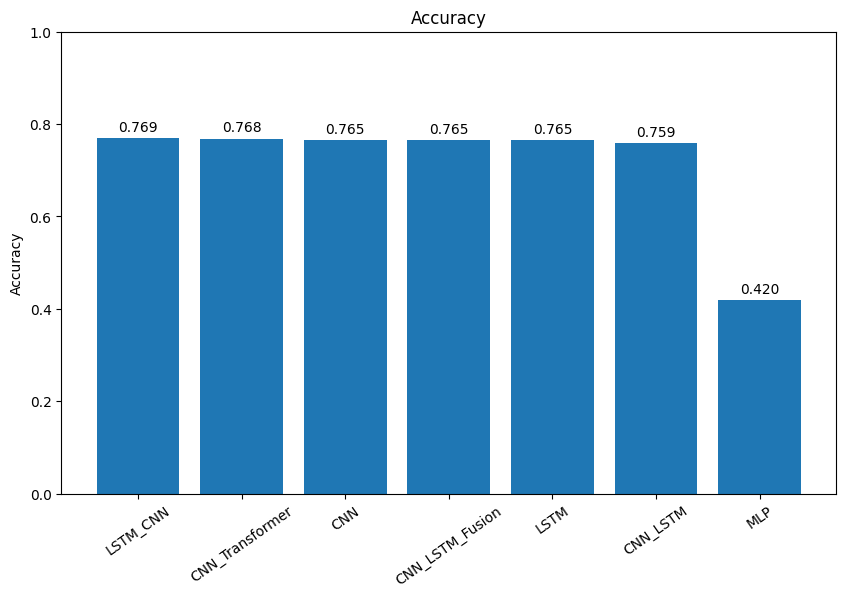

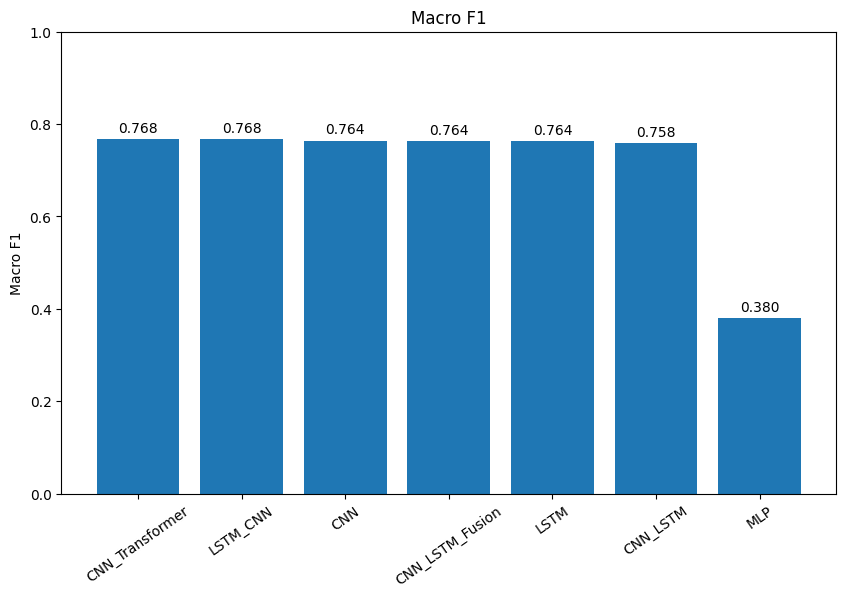

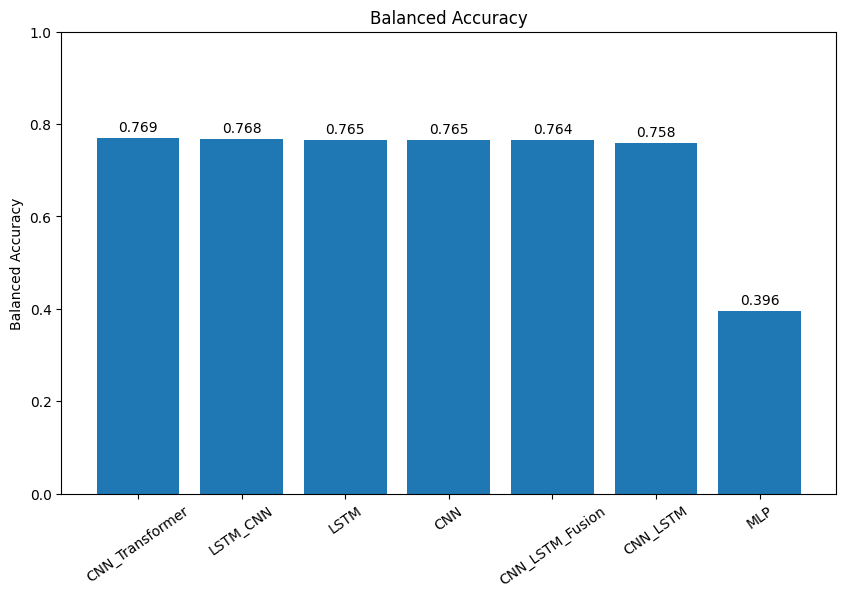

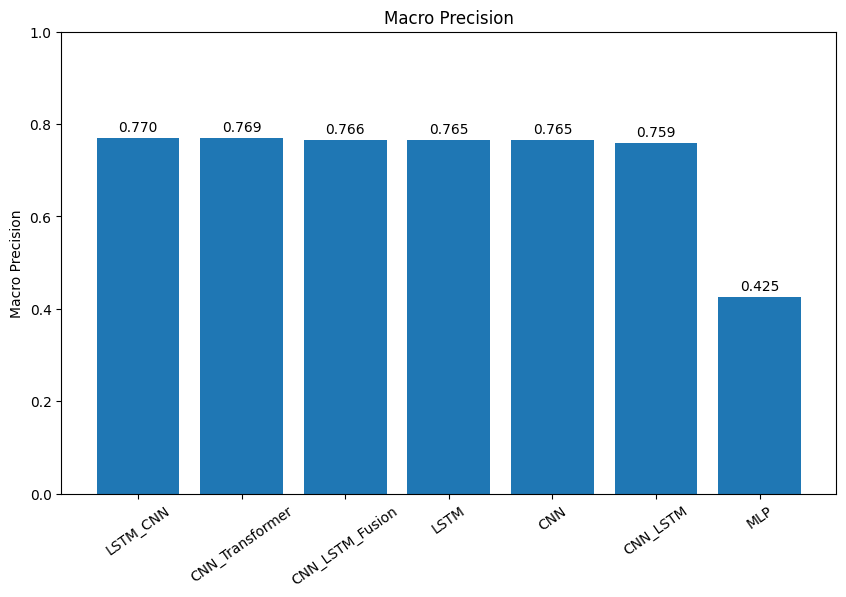

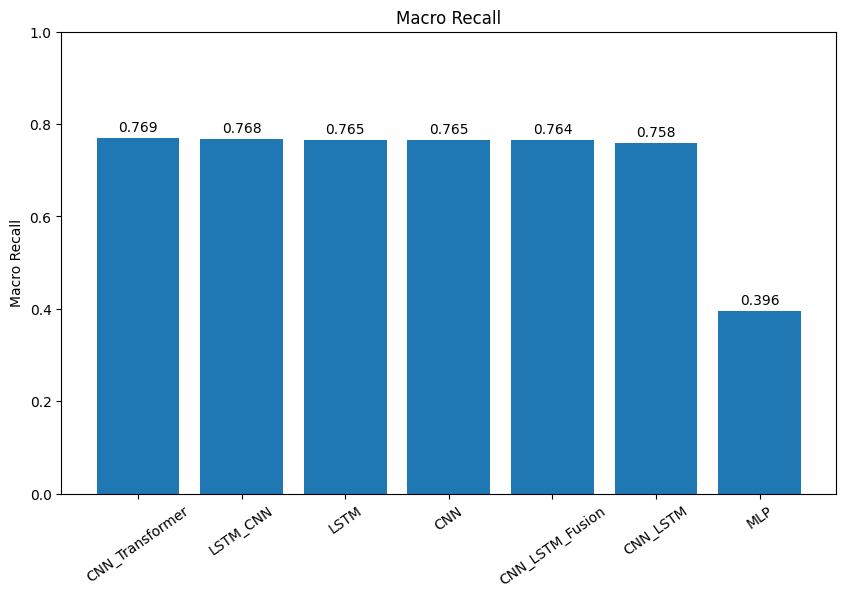

/tmp/ipykernel_1212/3555195461.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


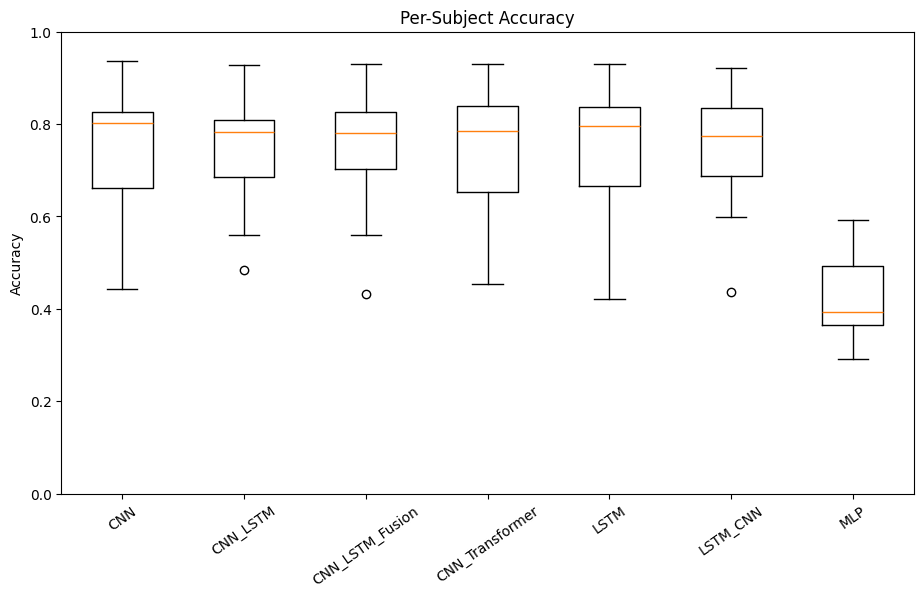

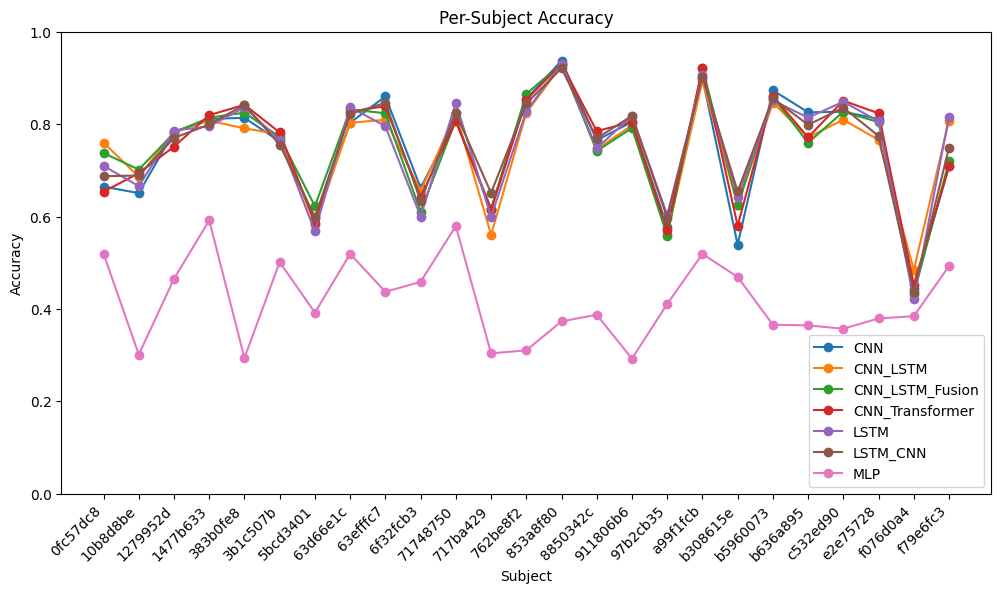

/tmp/ipykernel_1212/3555195461.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


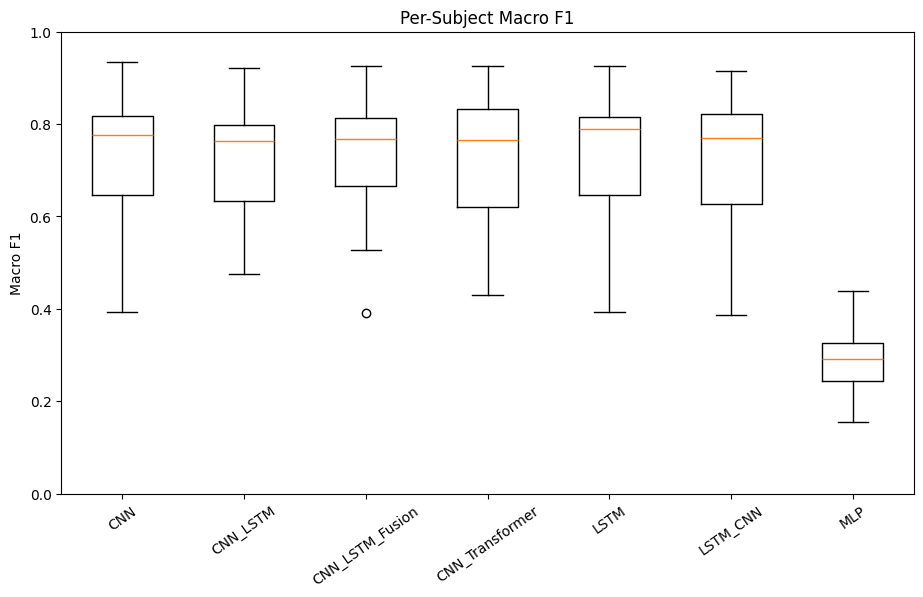

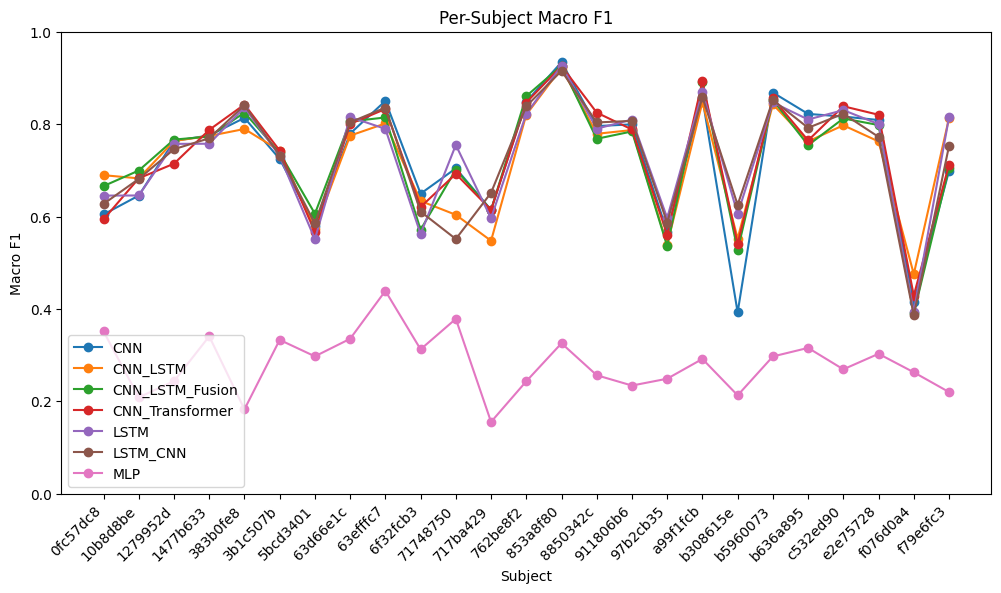

/tmp/ipykernel_1212/3555195461.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


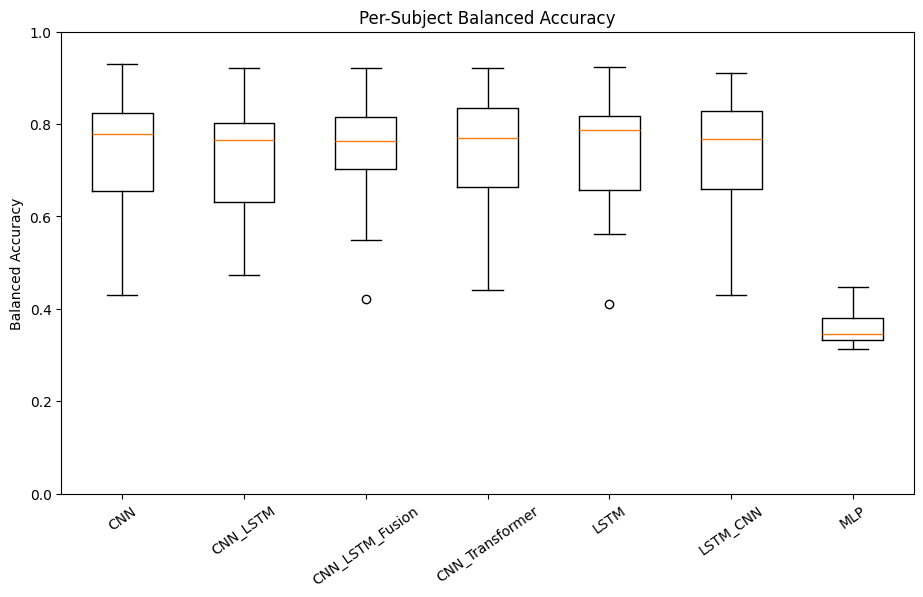

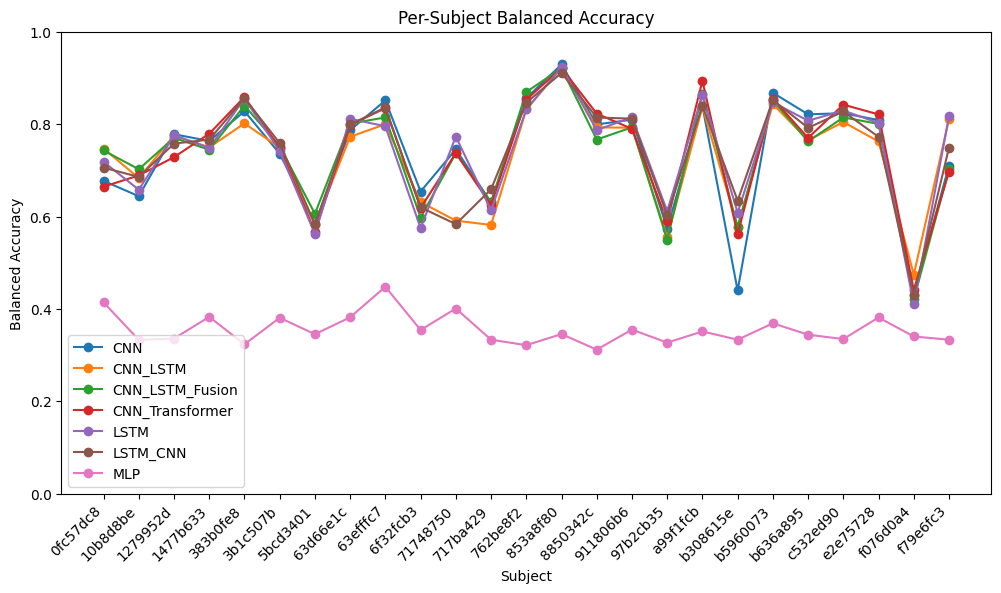

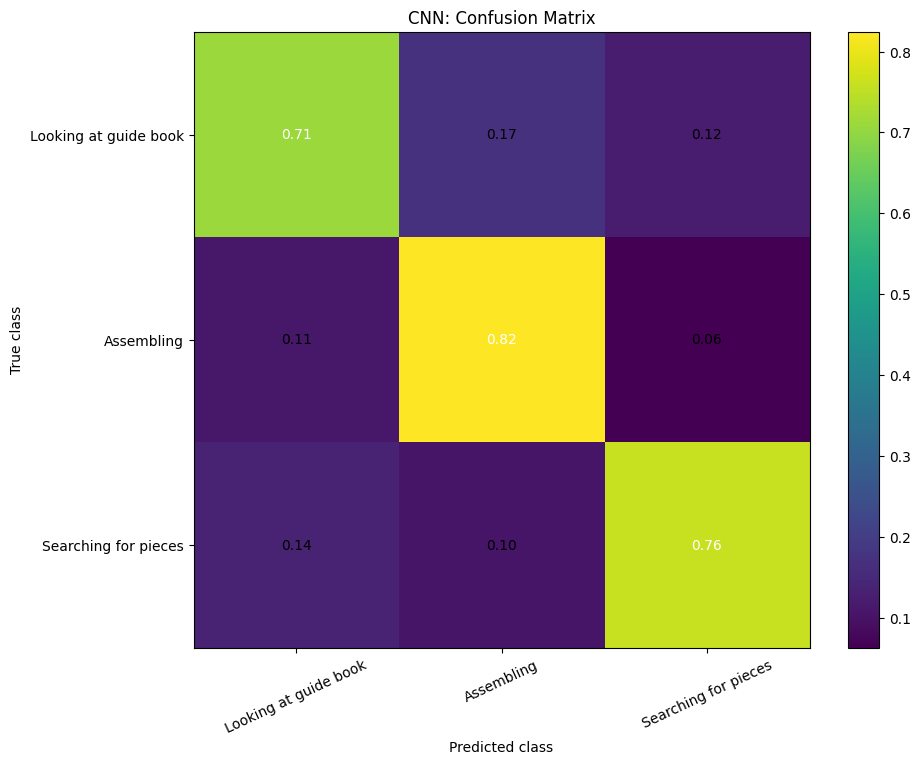

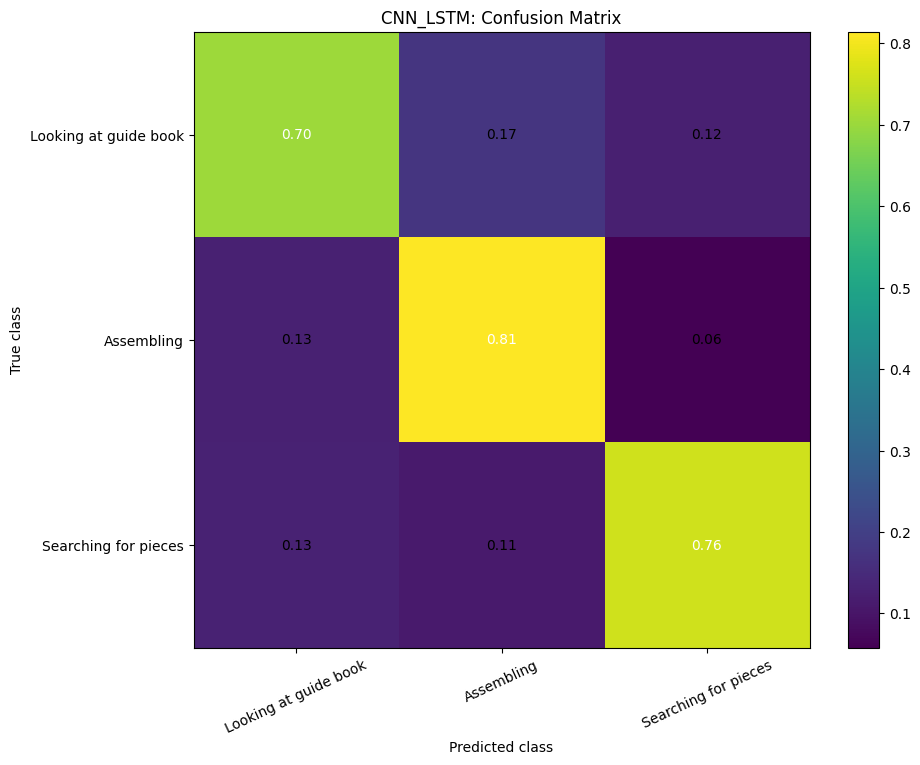

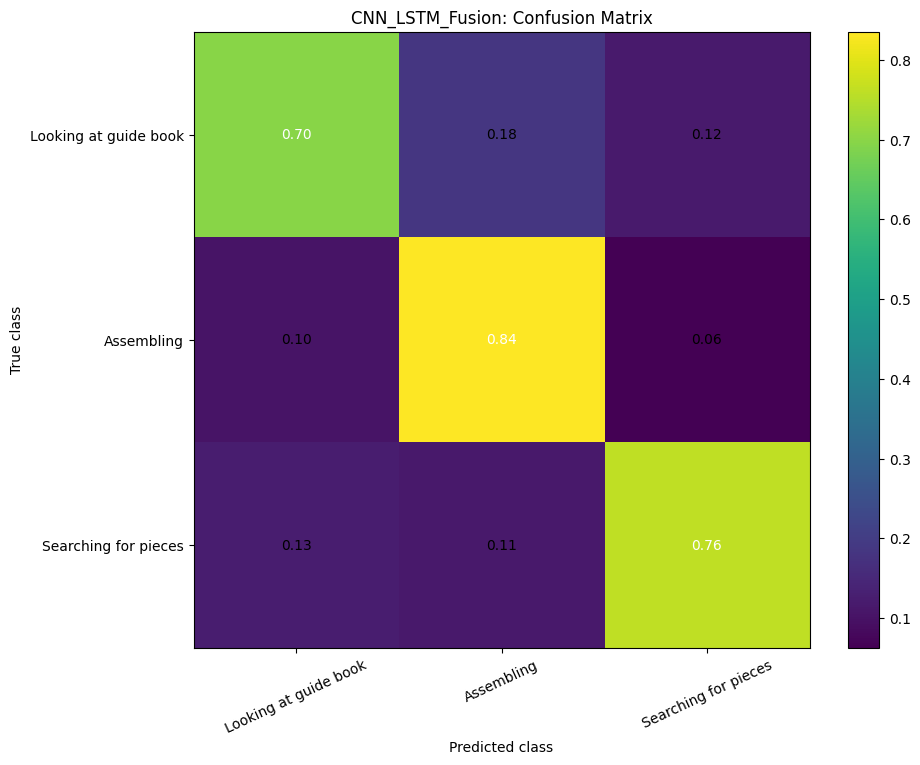

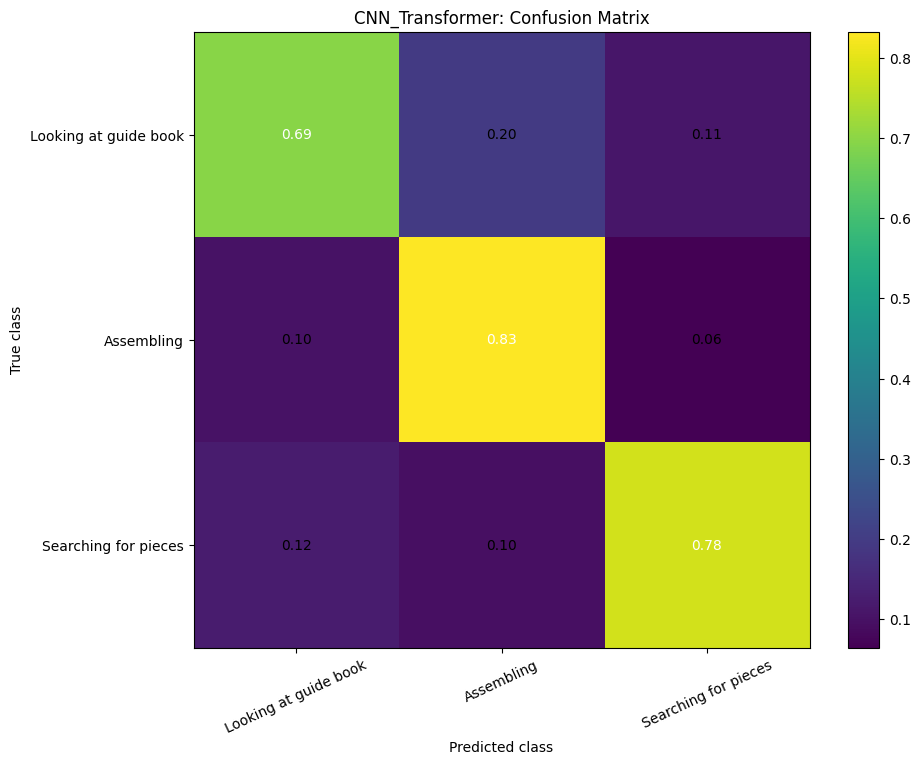

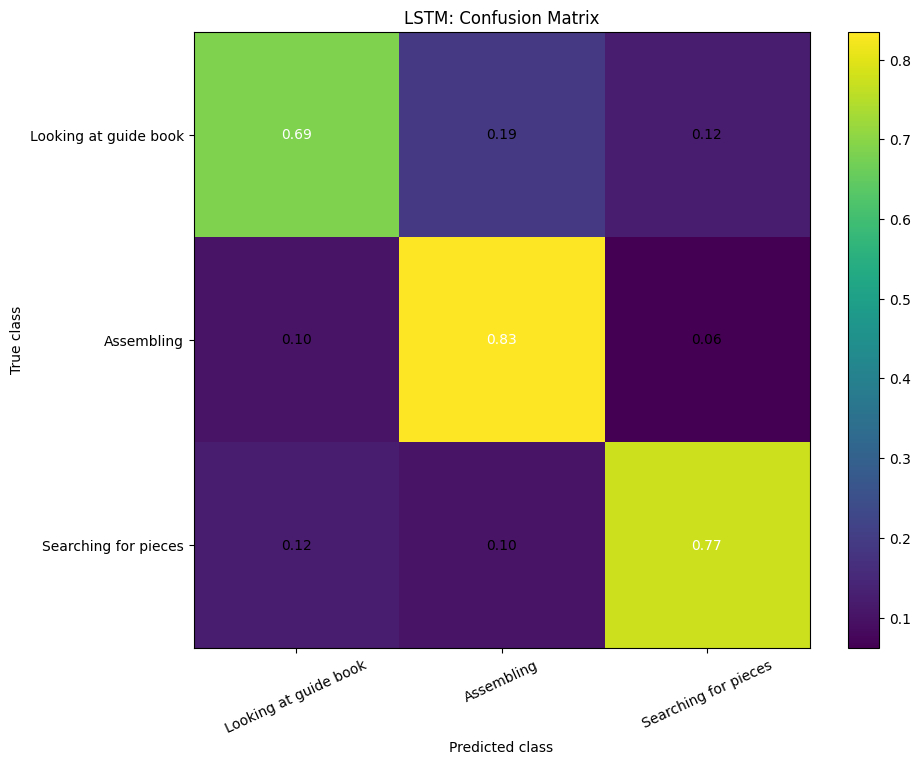

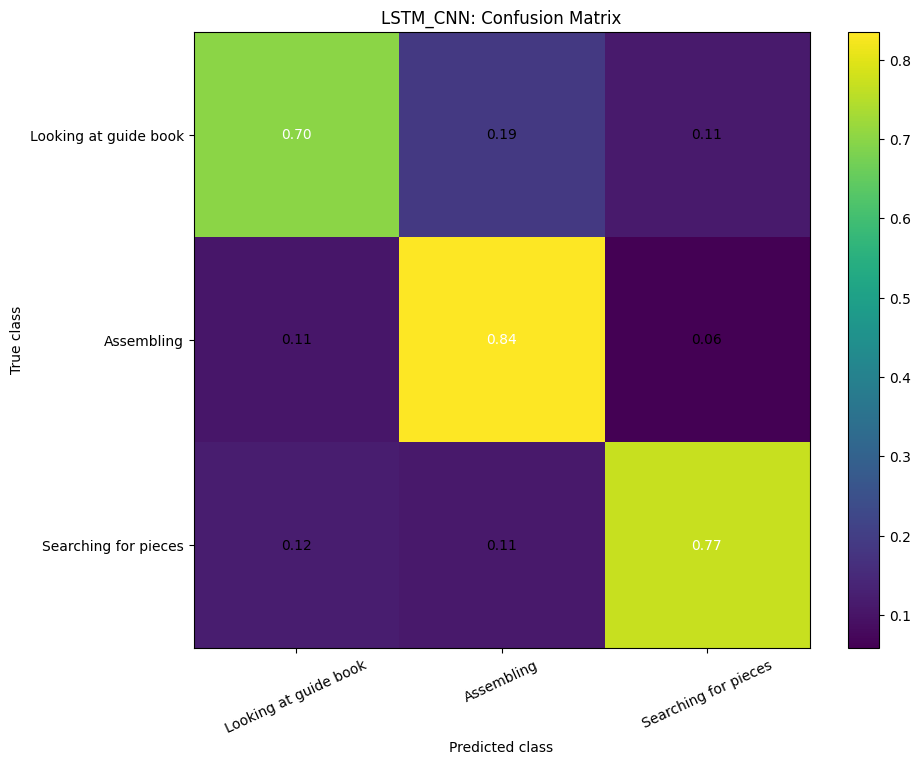

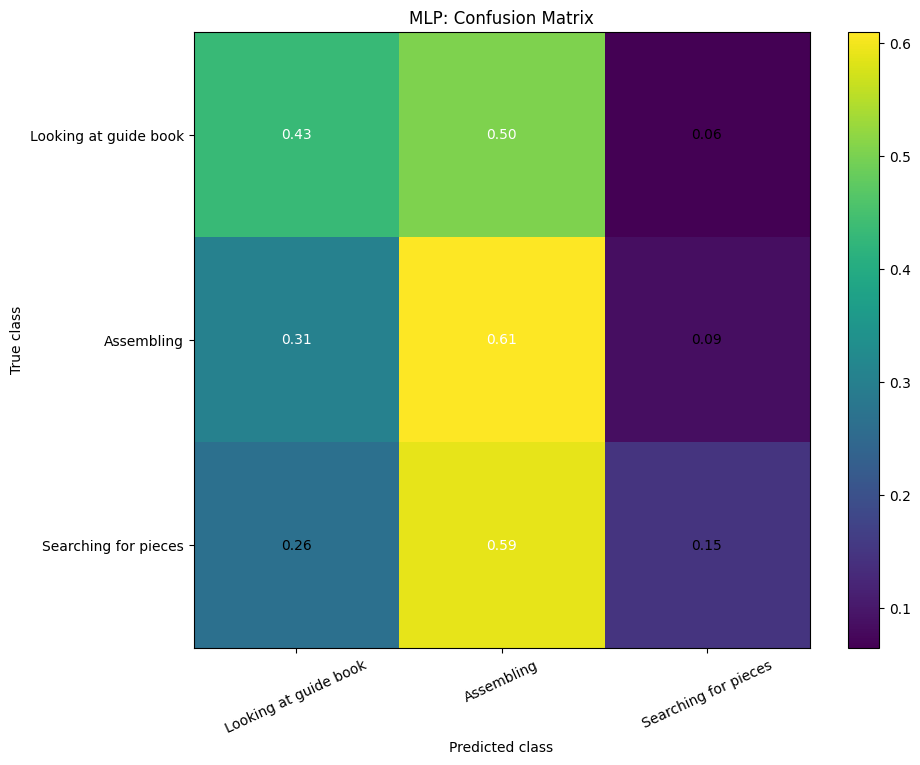

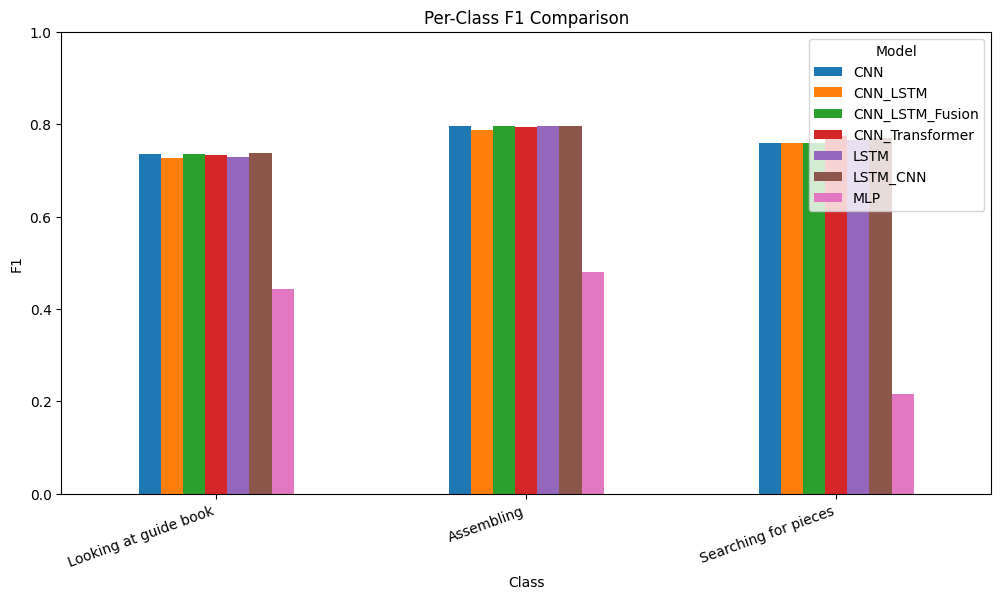

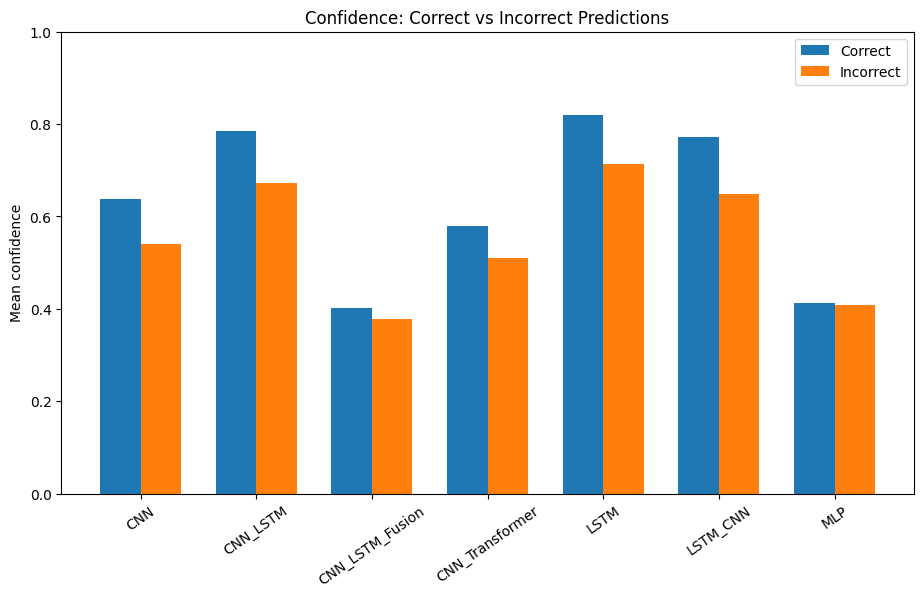

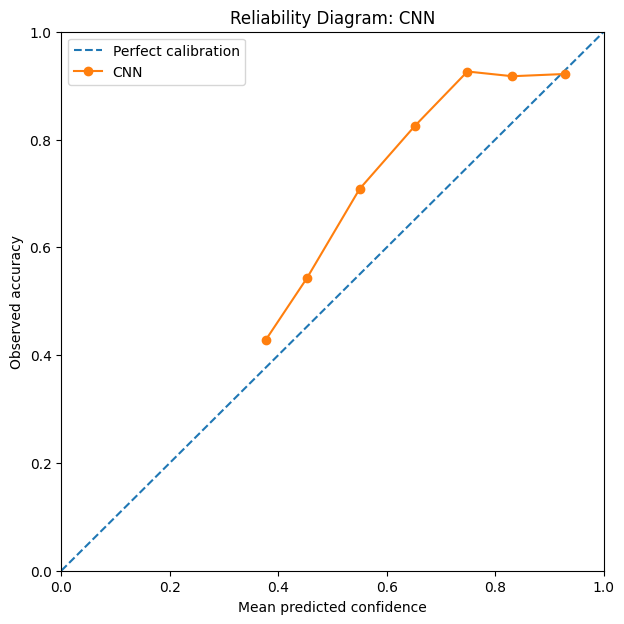

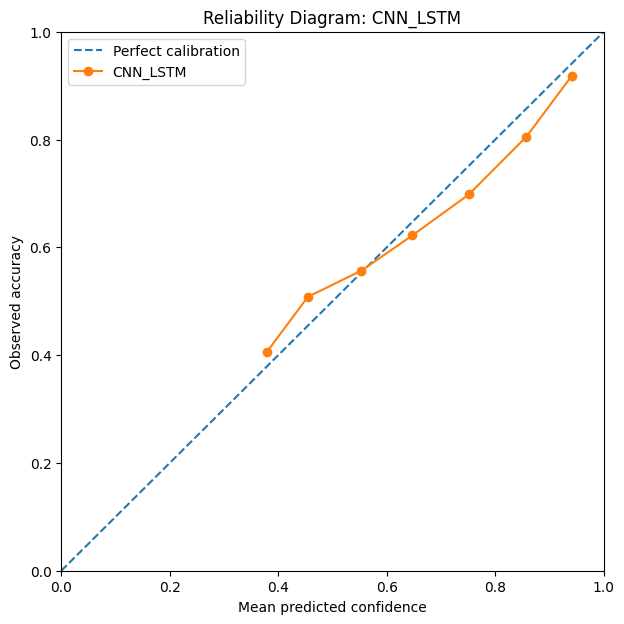

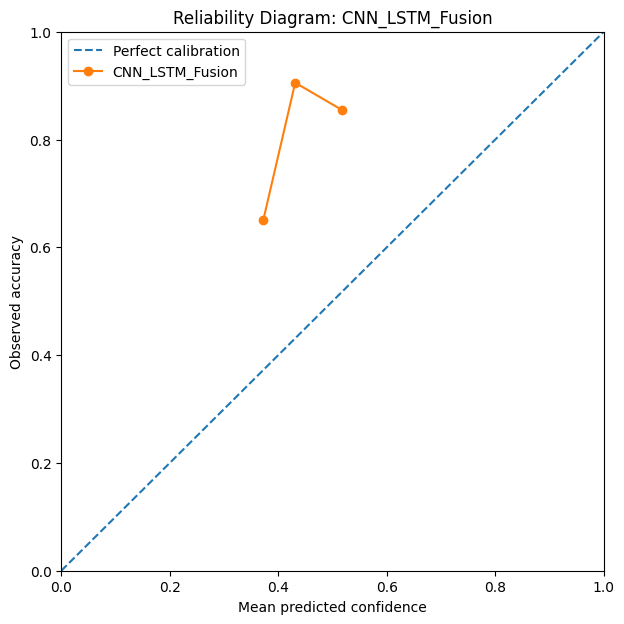

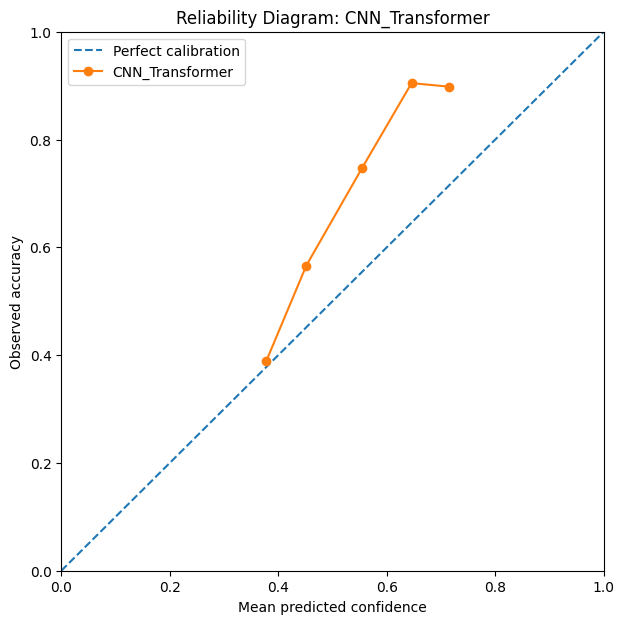

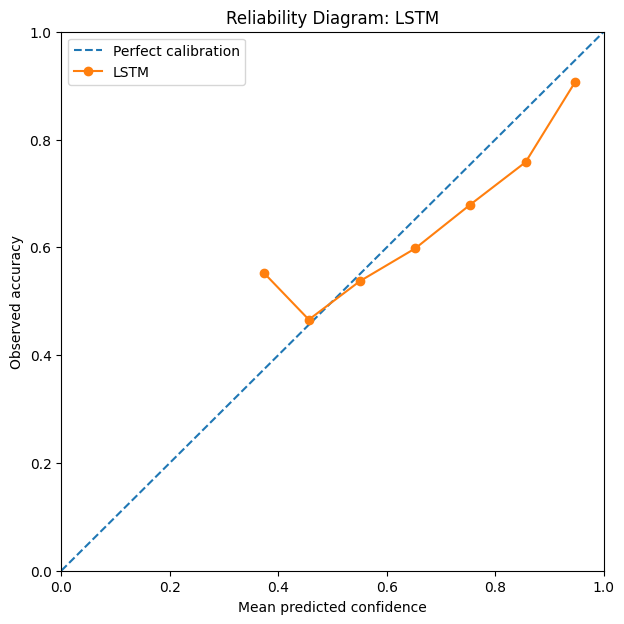

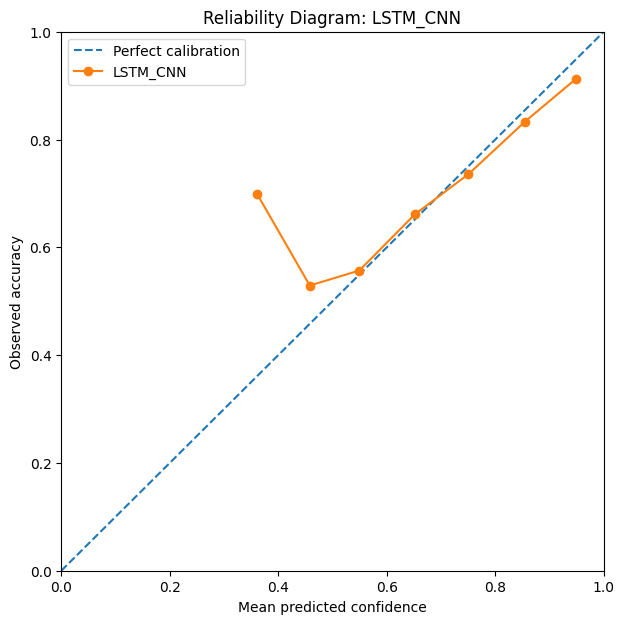

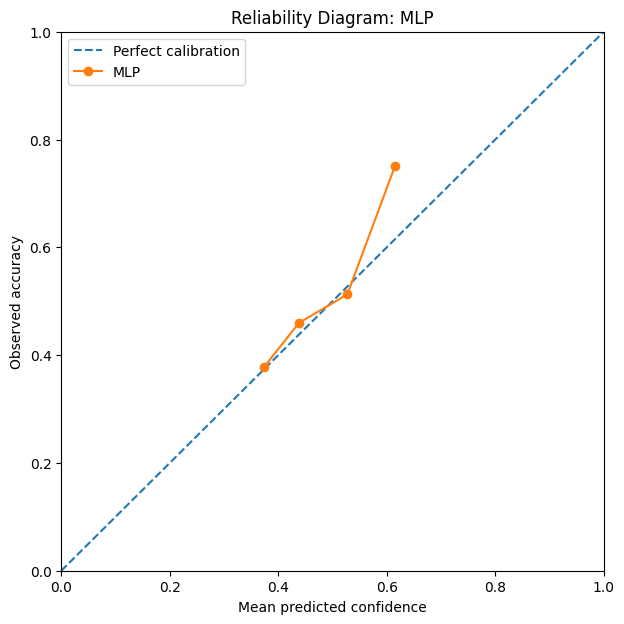

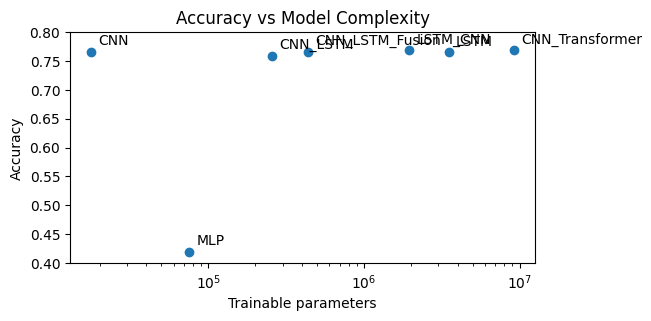

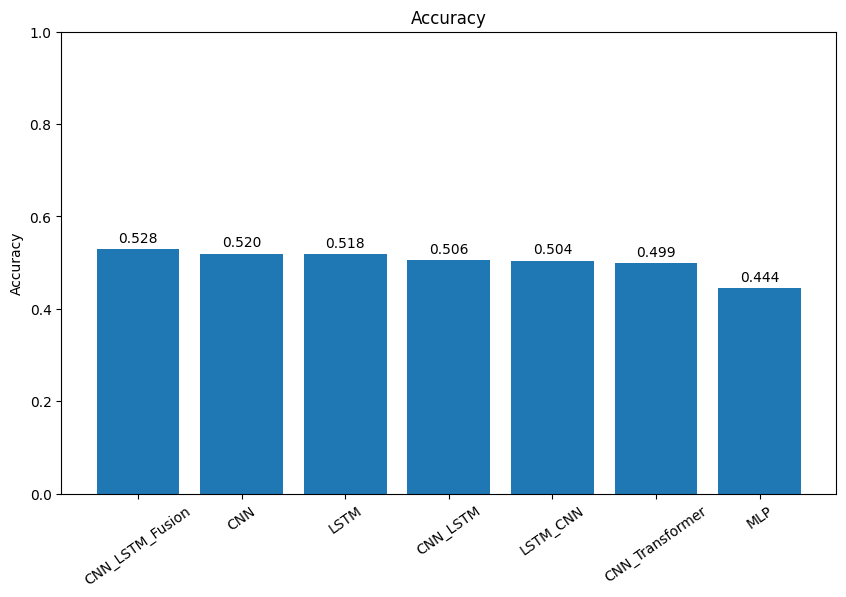

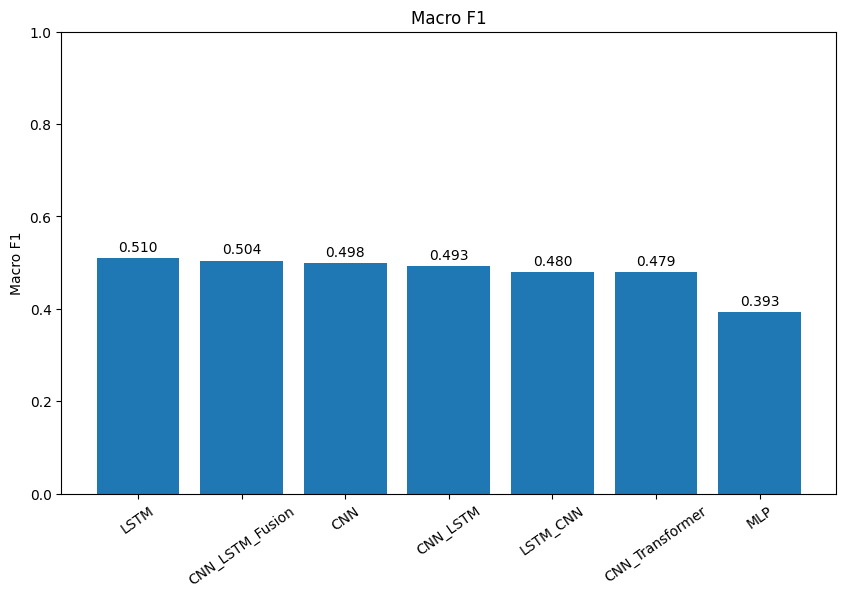

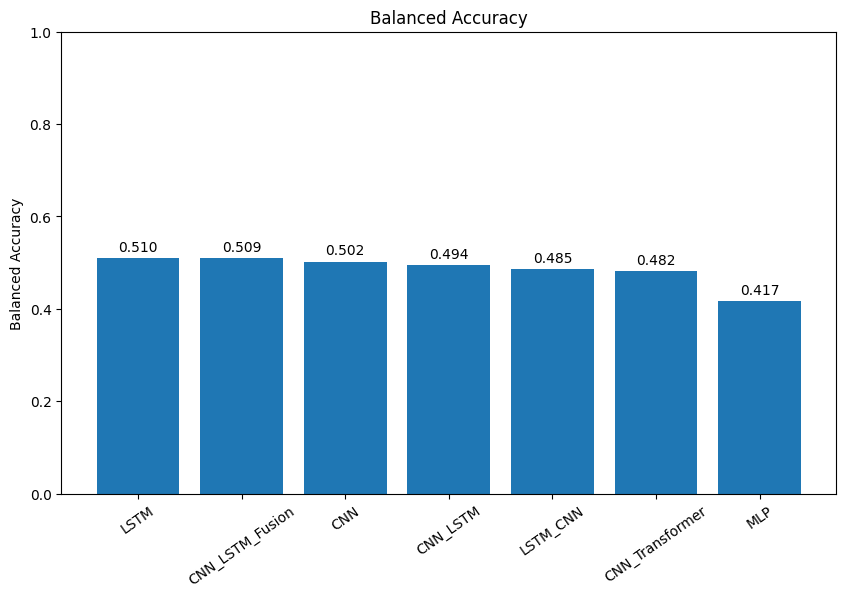

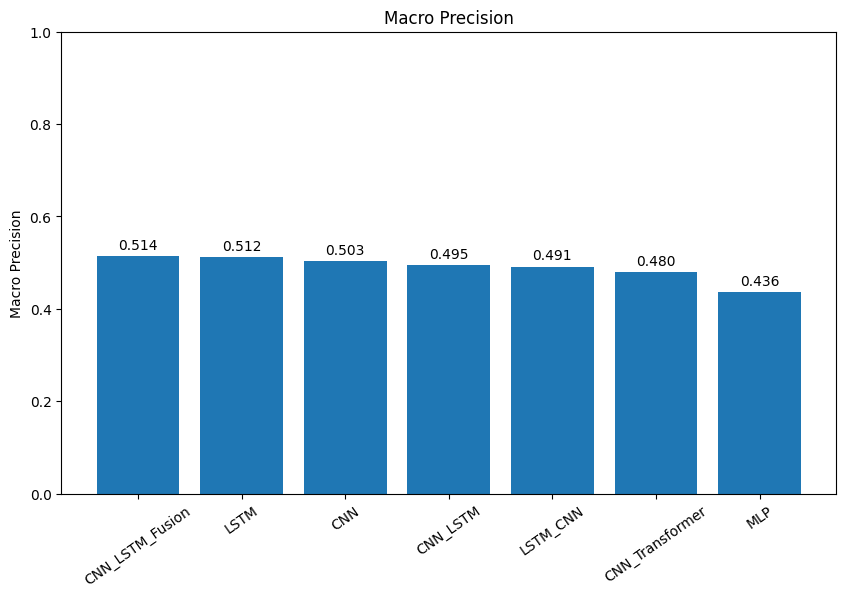

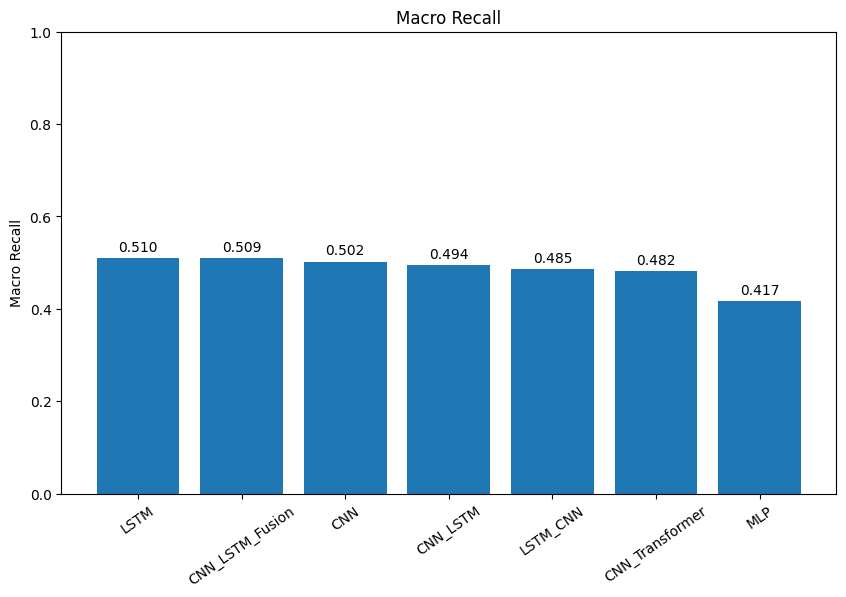

/tmp/ipykernel_1212/3555195461.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


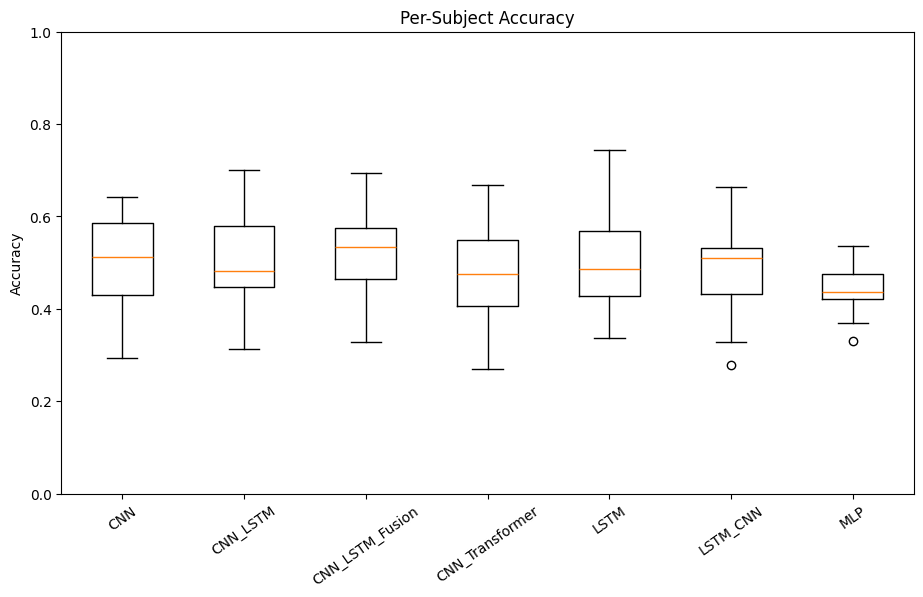

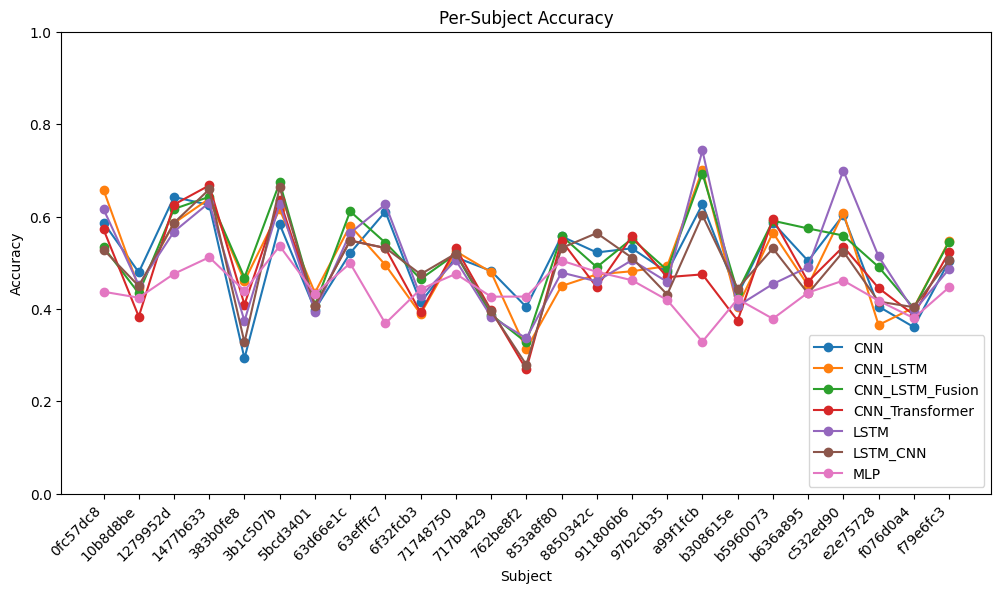

/tmp/ipykernel_1212/3555195461.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


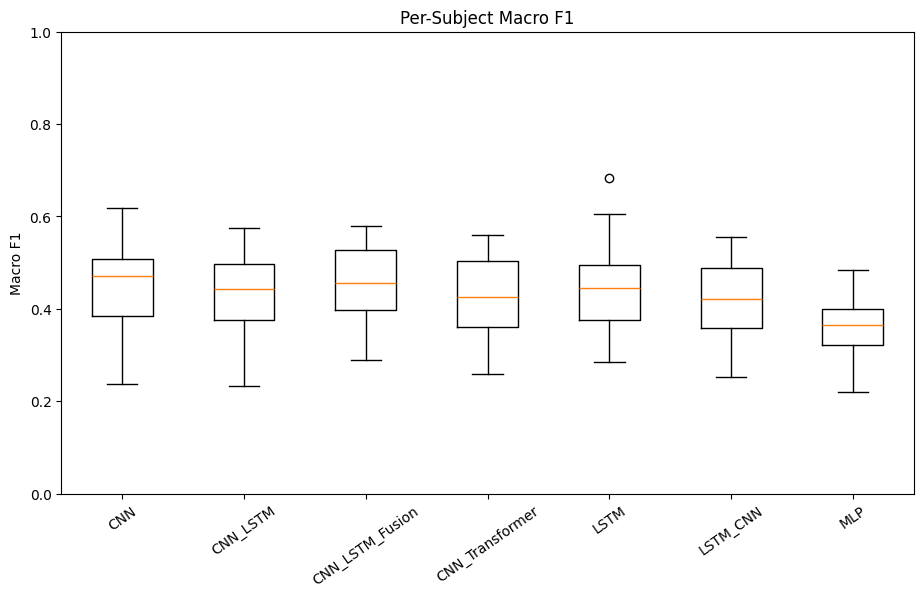

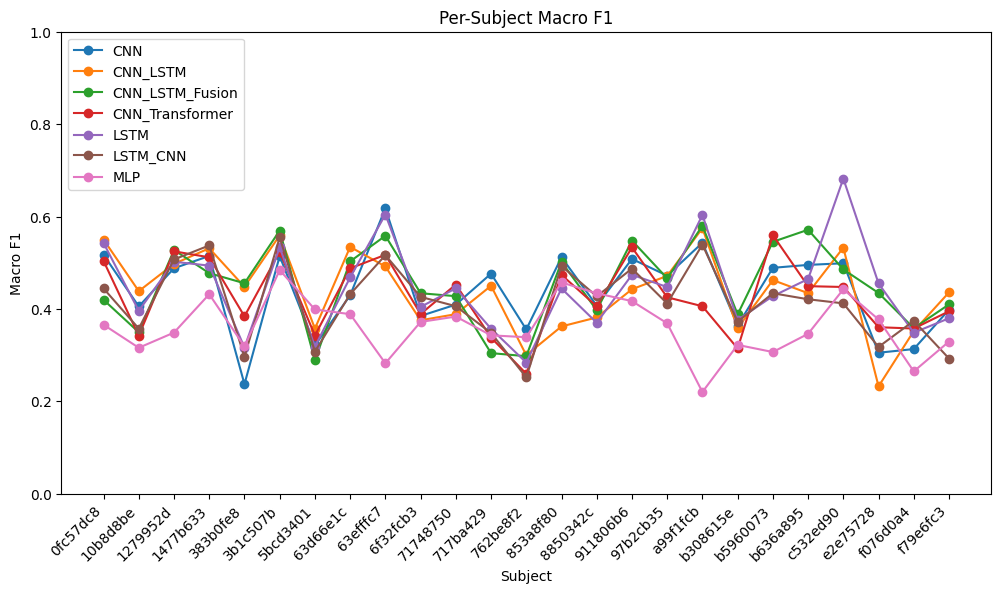

/tmp/ipykernel_1212/3555195461.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


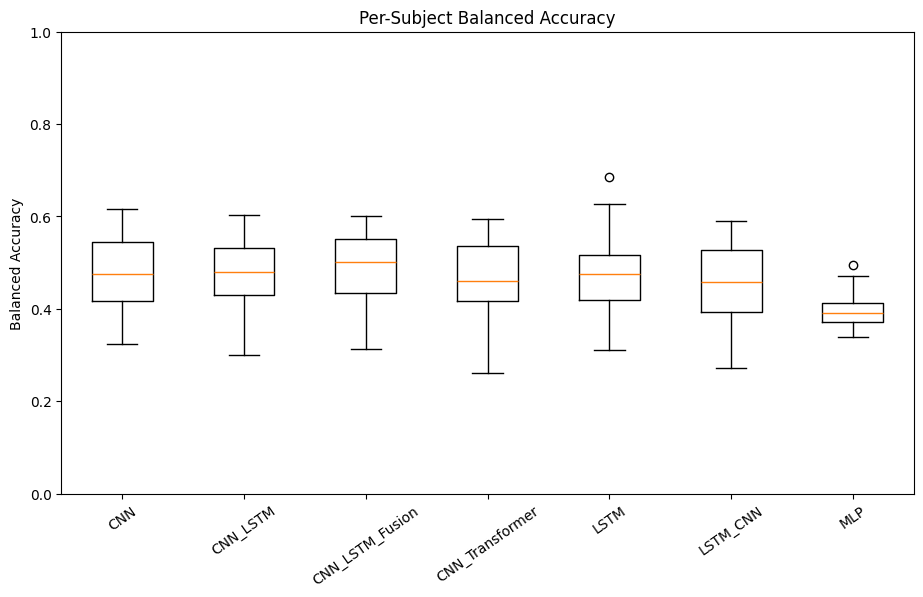

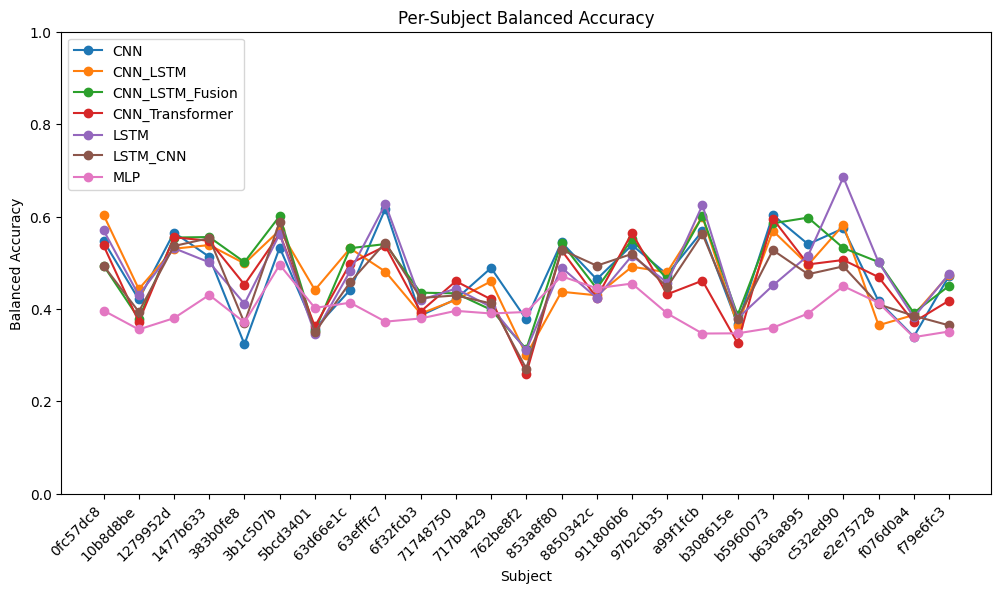

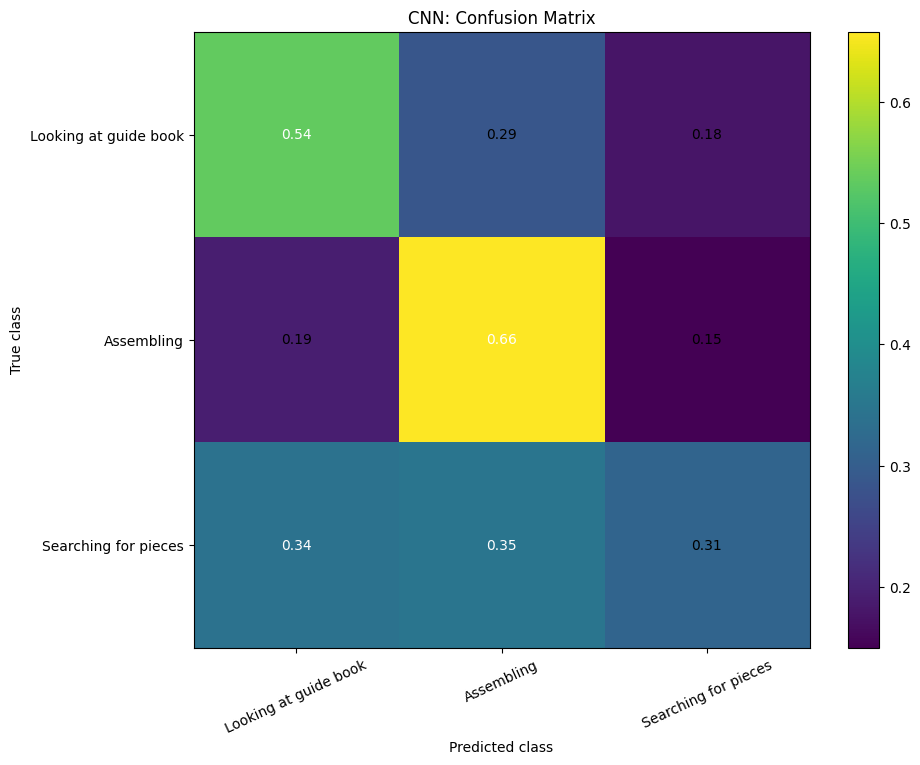

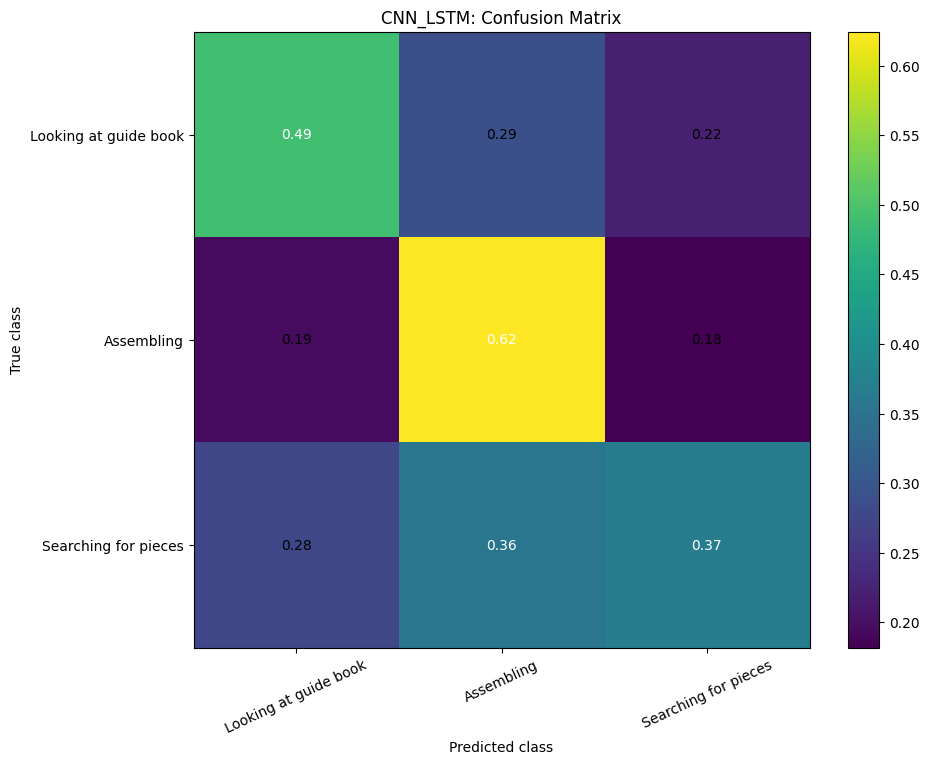

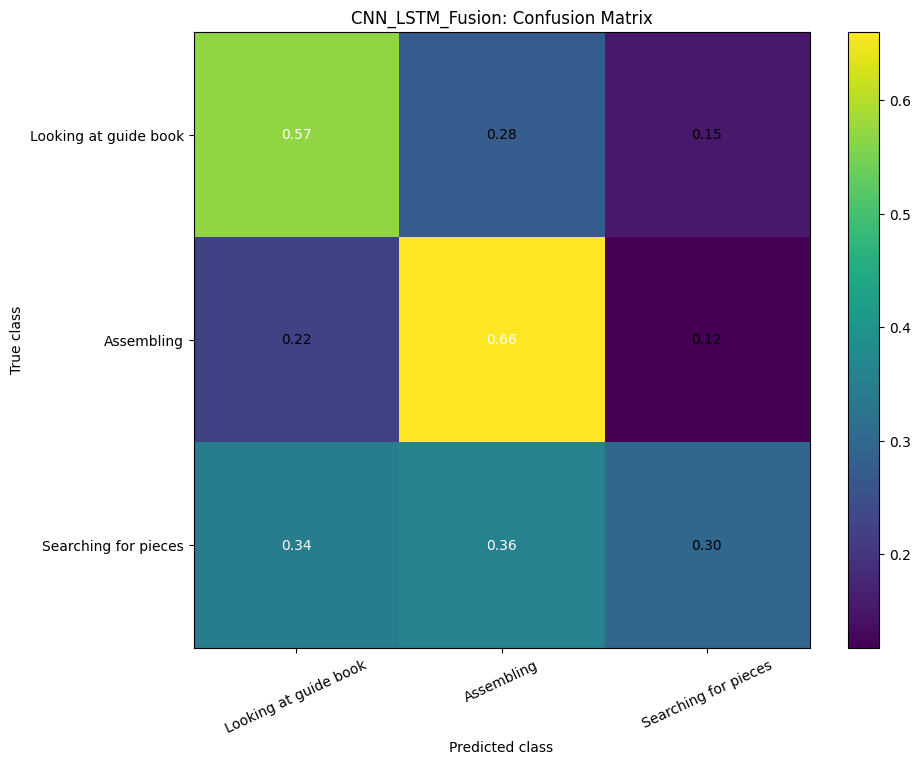

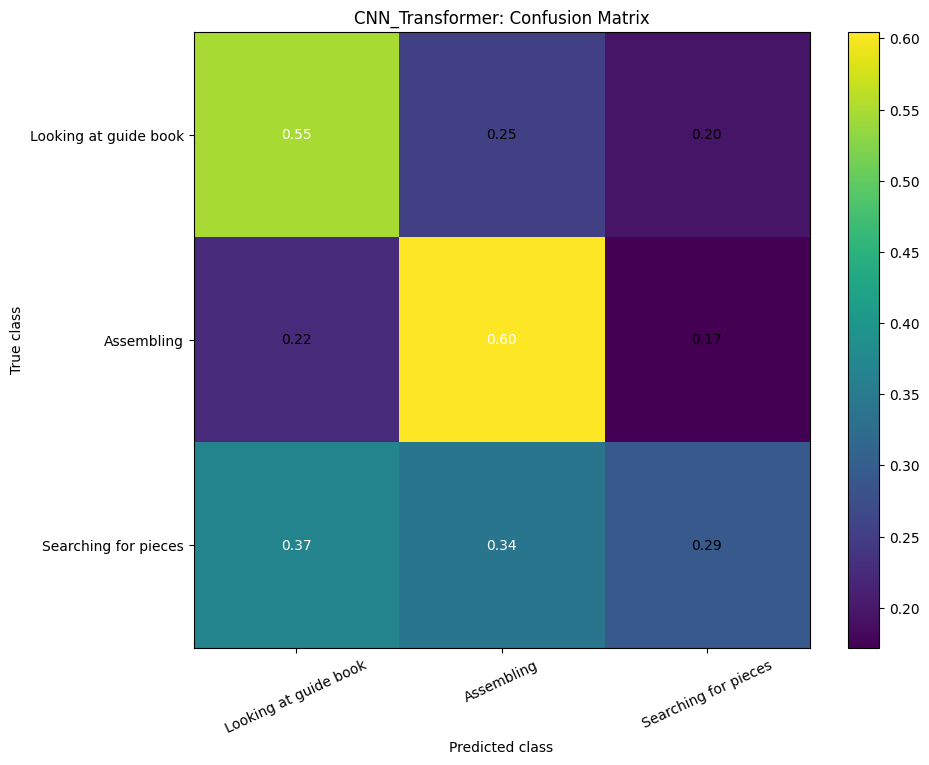

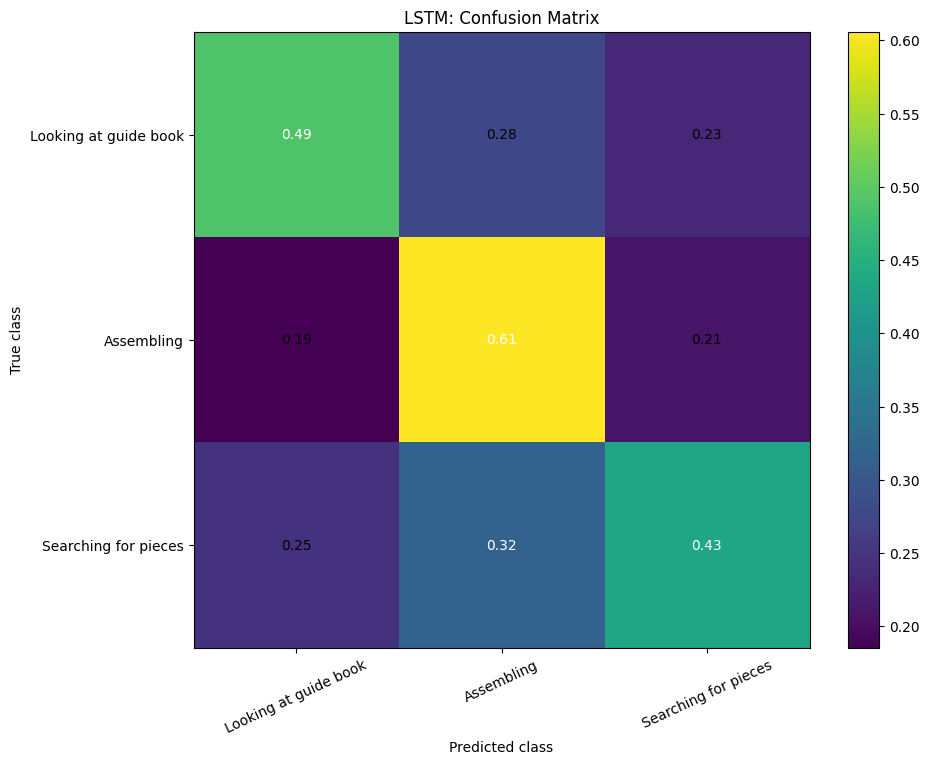

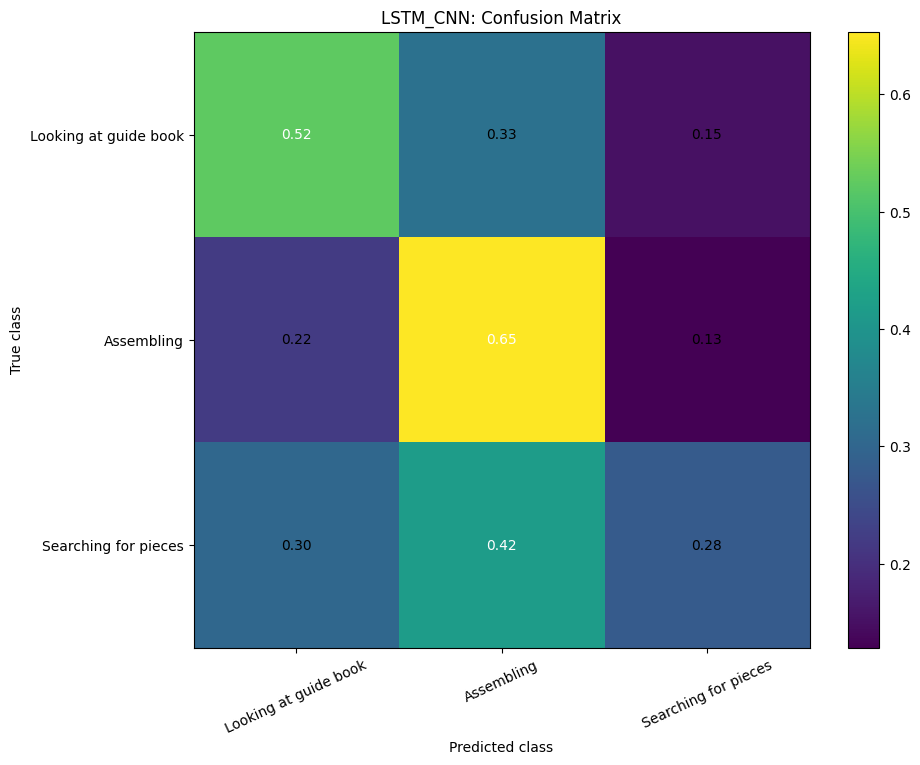

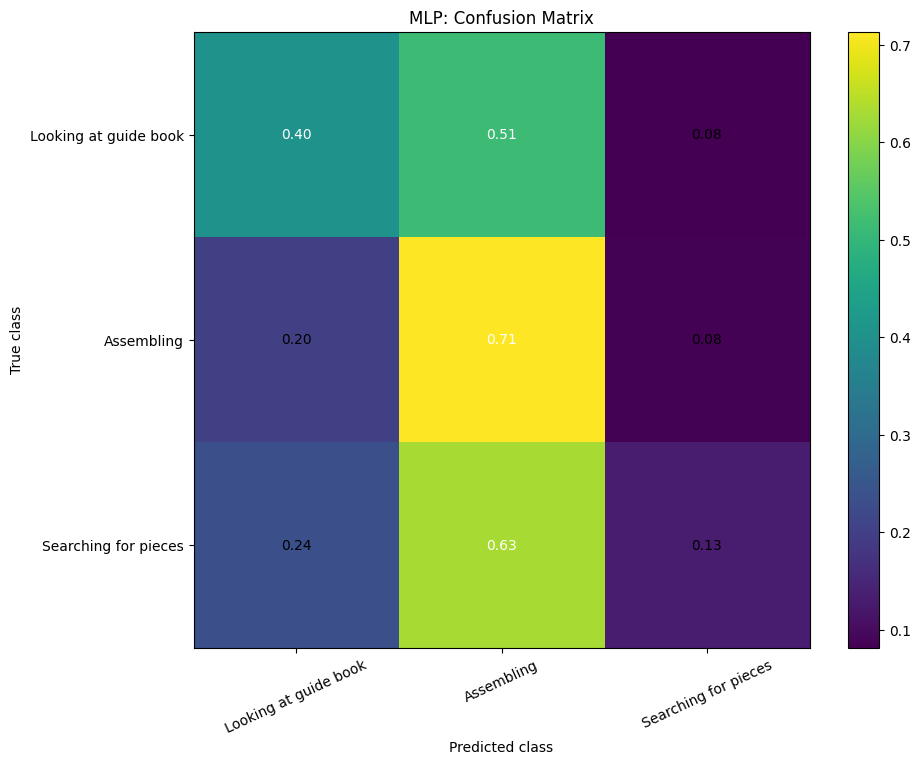

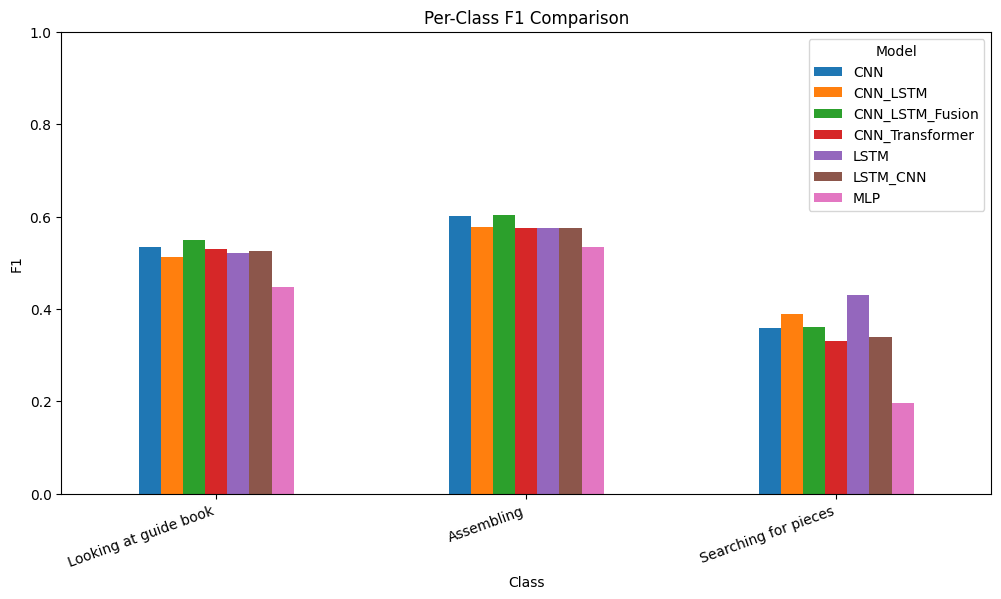

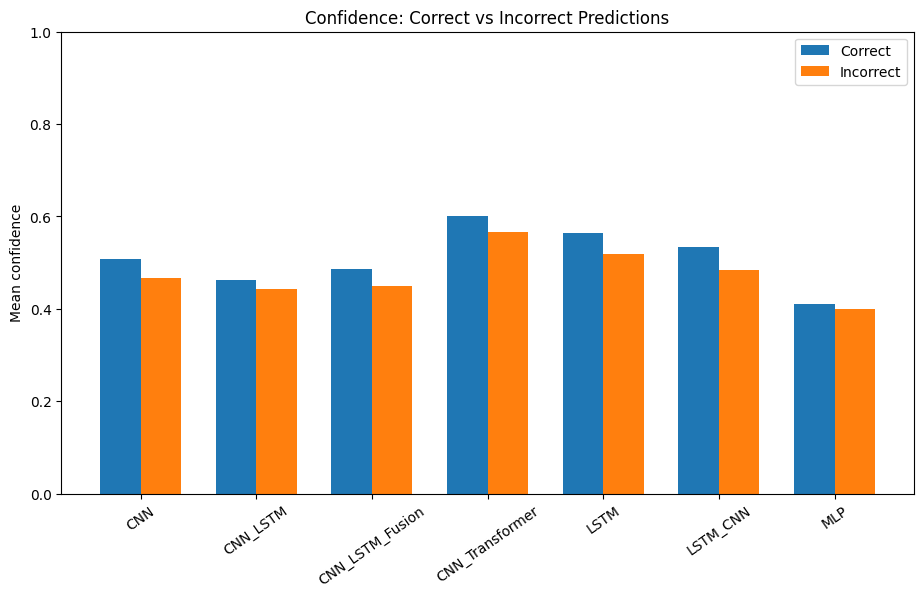

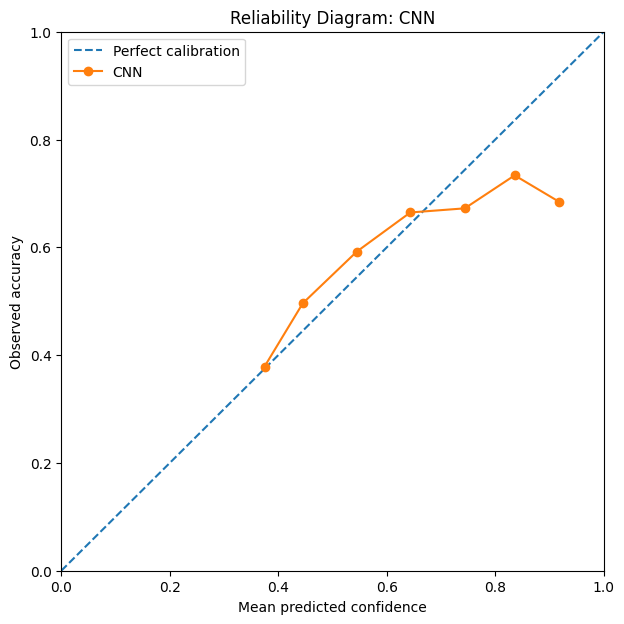

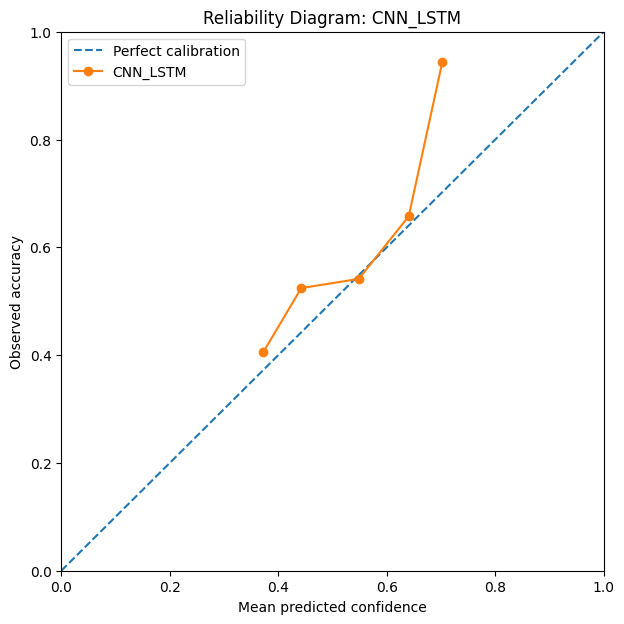

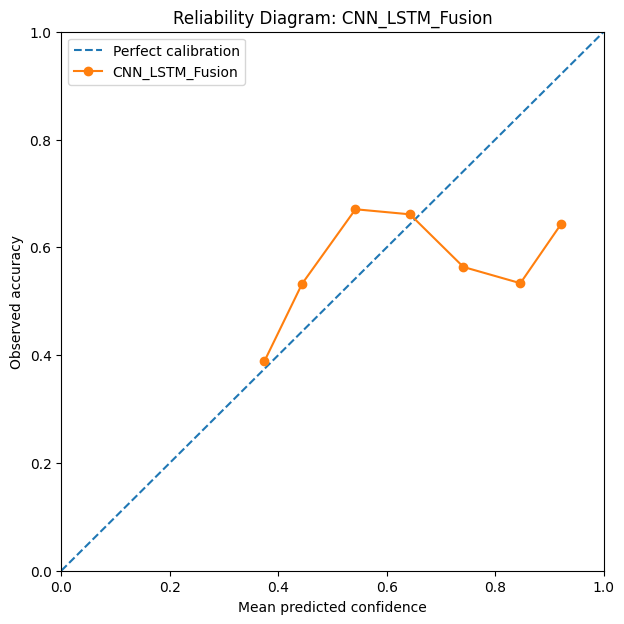

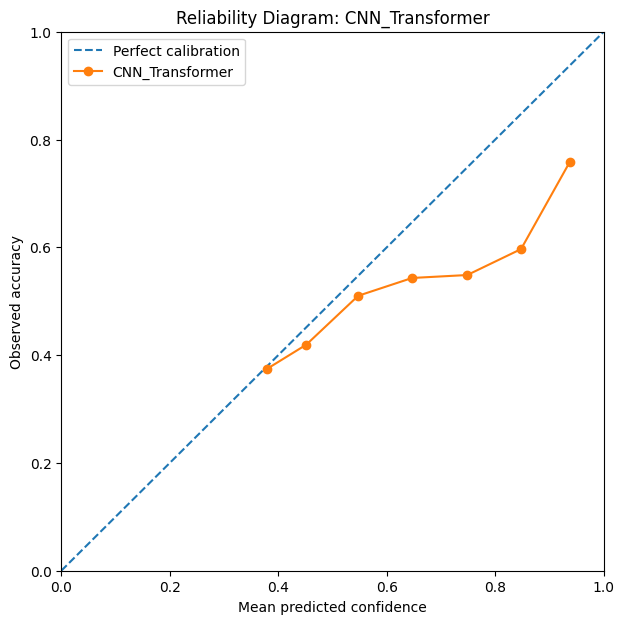

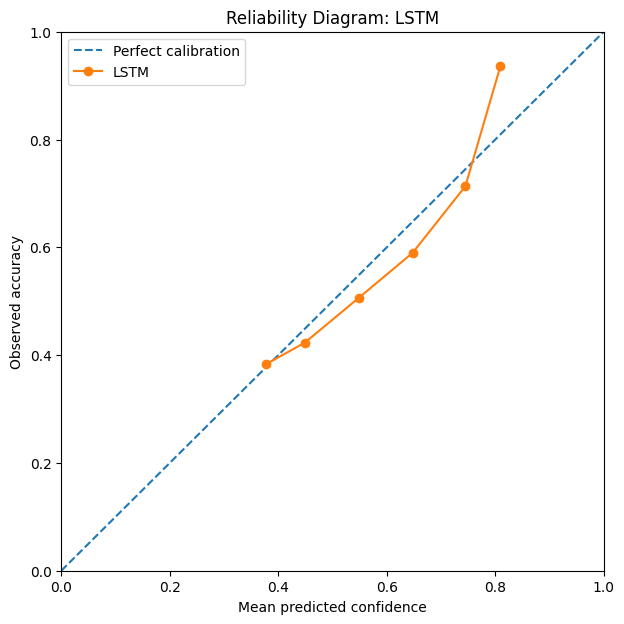

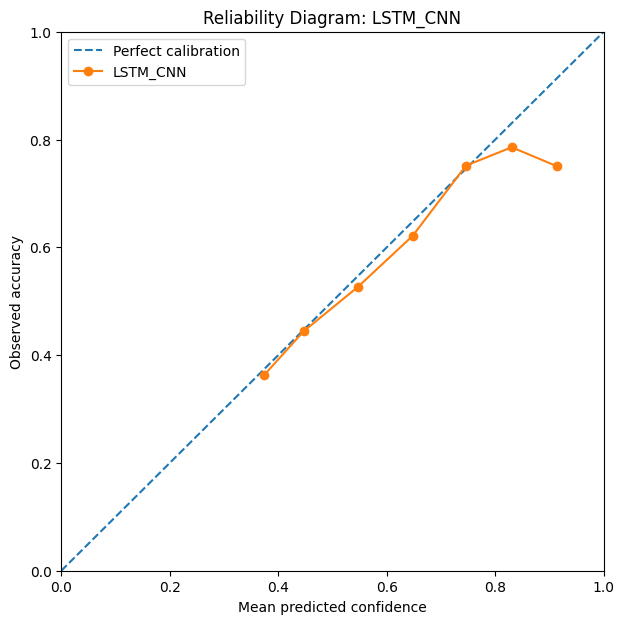

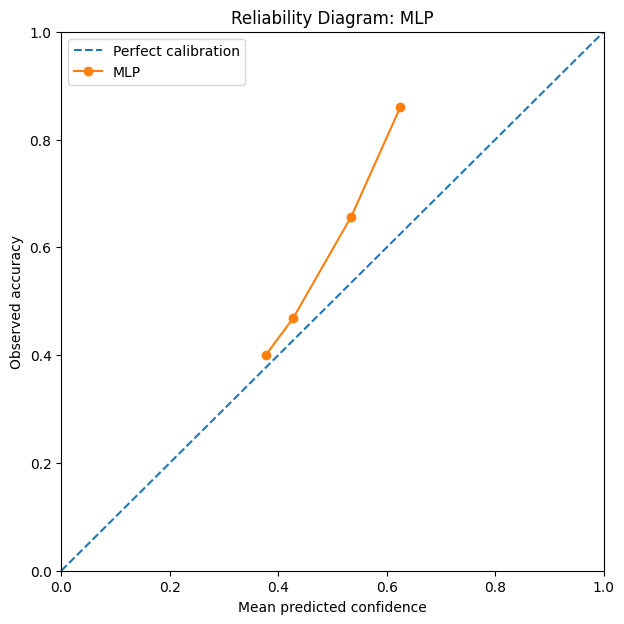

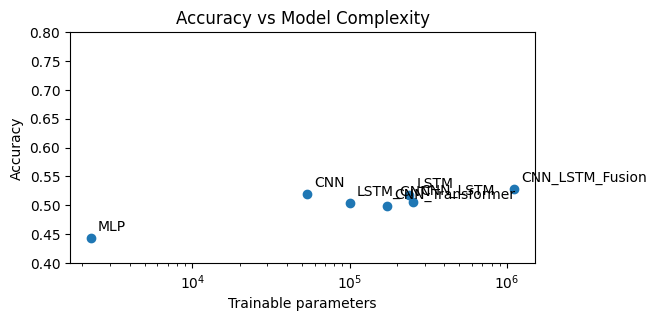

In [26]:
root = "../"

SUBJECT_ID_LENGTH = 8
CLASS_NAMES = {
    0: "Looking at guide book",
    1: "Assembling",
    2: "Searching for pieces",
}

EXPERIMENTS_ROOT = Path(root,"experiments")
EXPERIMENT_TYPE = "best_model"
EVAL_METRIC = "accuracy"
CSV_OUTPUT_PATH = Path(root, "results")
CSV_DEPENDENT_OUTPUT_PATH = Path(CSV_OUTPUT_PATH, "dependent")
CSV_INDEPENDENT_OUTPUT_PATH = Path(CSV_OUTPUT_PATH, "independent")

dependent = analyze_study(
    EXPERIMENTS_ROOT,
    EXPERIMENT_TYPE,
    EVAL_METRIC,
    "subject dependent",
    CSV_DEPENDENT_OUTPUT_PATH,
    True
)

independent = analyze_study(
    EXPERIMENTS_ROOT,
    EXPERIMENT_TYPE,
    EVAL_METRIC,
    "subject independent",
    CSV_INDEPENDENT_OUTPUT_PATH,
    True
)


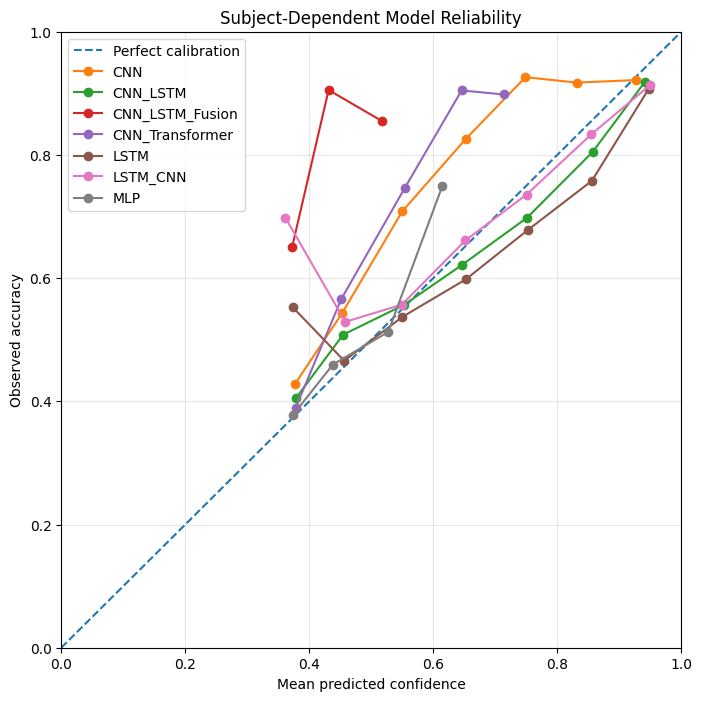

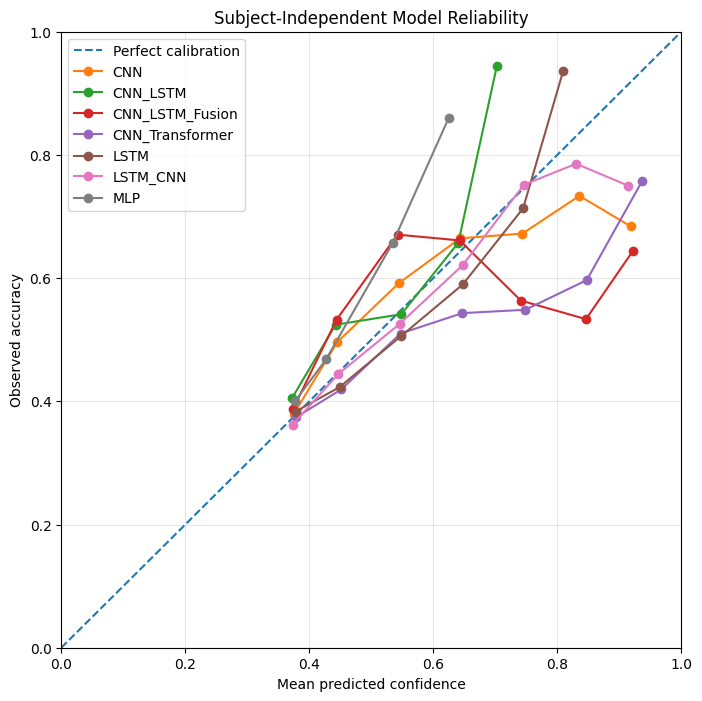

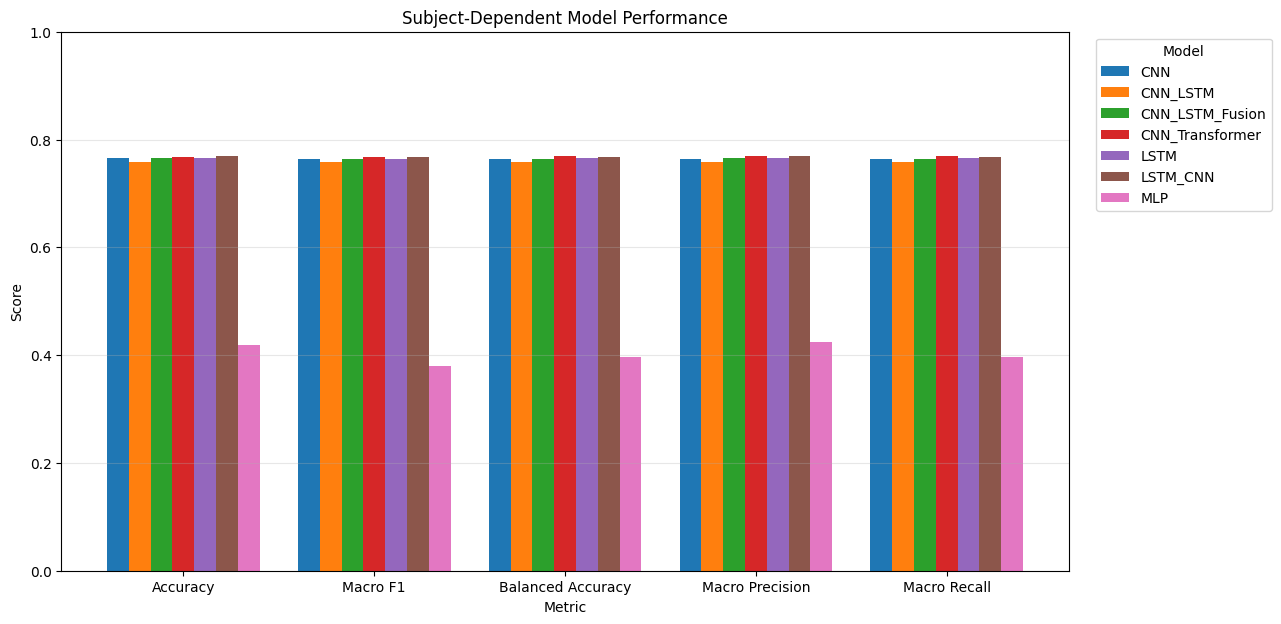

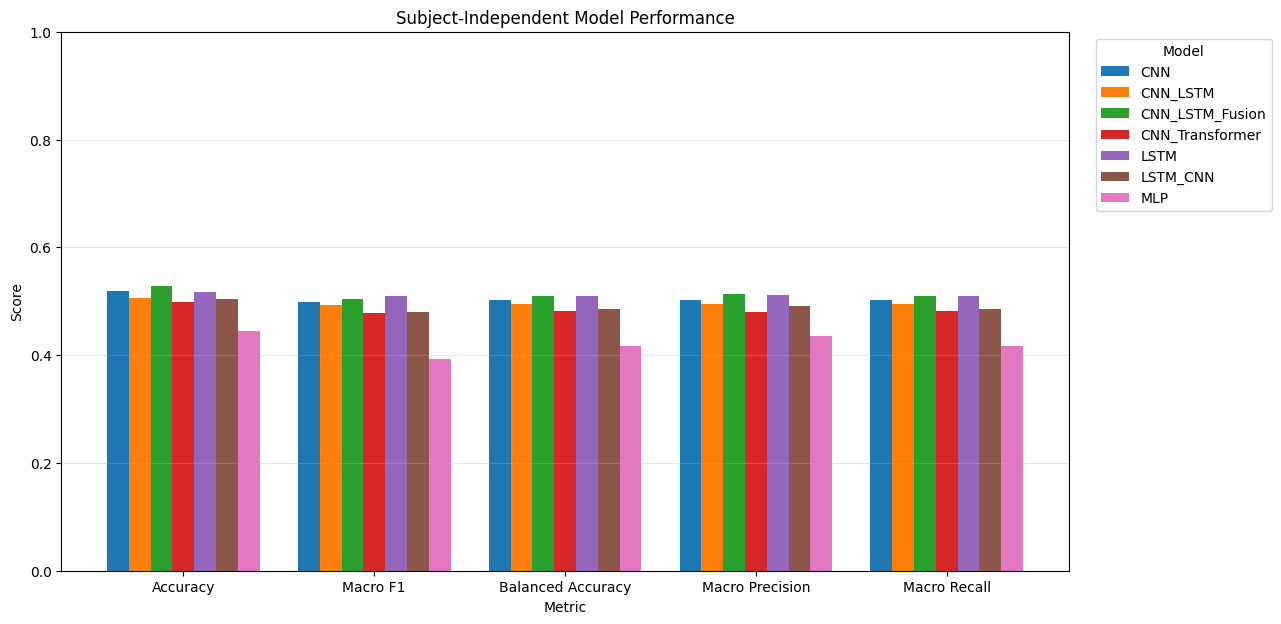

In [19]:
plot_combined_reliability_diagram(
    dependent["all_results"],
    save_path=Path(CSV_DEPENDENT_OUTPUT_PATH,"figures", "reliability_comparison.png"),
    title="Subject-Dependent Model Reliability",
)

plot_combined_reliability_diagram(
    independent["all_results"],
    save_path=Path(CSV_INDEPENDENT_OUTPUT_PATH,"figures", "reliability_comparison.png"),
    title="Subject-Independent Model Reliability",
)

plot_main_metrics_comparison(
    dependent["pooled_metrics"],
    save_path=Path(CSV_DEPENDENT_OUTPUT_PATH,"figures", "main_metrics_comparison.png"),
    title="Subject-Dependent Model Performance",
)

plot_main_metrics_comparison(
    independent["pooled_metrics"],
    save_path=Path(CSV_INDEPENDENT_OUTPUT_PATH,"figures", "main_metrics_comparison.png"),
    title="Subject-Independent Model Performance",
)

In [20]:
export_analysis(dependent, CSV_DEPENDENT_OUTPUT_PATH)
export_analysis(independent, CSV_INDEPENDENT_OUTPUT_PATH)

In [21]:
export_complete_analysis(
    dependent,
    Path(CSV_DEPENDENT_OUTPUT_PATH, "subject_dependent_all_results.csv"),
)

export_complete_analysis(
    independent,
    Path(CSV_INDEPENDENT_OUTPUT_PATH, "subject_independent_all_results.csv"),
)

Exported: ../results/dependent/subject_dependent_all_results.csv
Rows: 700
Exported: ../results/independent/subject_independent_all_results.csv
Rows: 700


In [22]:
display_key_results(dependent)

Overall performance


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,n_samples,n_subjects
0,CNN,0.765483,0.764543,0.764660,0.764543,0.763954,10366,25
1,CNN_LSTM,0.758923,0.758403,0.758597,0.758403,0.757939,10366,25
2,CNN_LSTM_Fusion,0.765483,0.764479,0.765682,0.764479,0.763773,10366,25
3,CNN_Transformer,0.768377,0.768684,0.769117,0.768684,0.767582,10366,25
4,LSTM,0.765001,0.765184,0.765148,0.765184,0.763626,10366,25
5,LSTM_CNN,0.768667,0.768151,0.769545,0.768151,0.767560,10366,25
6,MLP,0.419641,0.395762,0.424759,0.395762,0.380435,10366,25



Subject-level summary


,model,accuracy_mean,accuracy_std,accuracy_median,accuracy_min,accuracy_max,accuracy_q1,accuracy_q3,macro_f1_mean,macro_f1_std,macro_f1_median,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_median
0,CNN,0.747946,0.123580,0.802885,0.442105,0.937294,0.662069,0.825581,0.725089,0.137700,0.775431,0.735468,0.128675,0.778101
1,CNN_LSTM,0.747947,0.110720,0.783422,0.484211,0.927393,0.686224,0.809524,0.723047,0.116123,0.763492,0.729288,0.112350,0.764889
2,CNN_LSTM_Fusion,0.751196,0.118176,0.780749,0.431579,0.930693,0.701531,0.824859,0.727436,0.127865,0.766501,0.737406,0.117098,0.762676
3,CNN_Transformer,0.750720,0.121984,0.784736,0.452632,0.930693,0.653631,0.838936,0.731583,0.127373,0.764664,0.740208,0.120755,0.770032
4,LSTM,0.753398,0.121992,0.795518,0.421053,0.930693,0.665816,0.836158,0.734314,0.126088,0.789754,0.743285,0.120363,0.787052
5,LSTM_CNN,0.755056,0.112304,0.774476,0.436842,0.920792,0.687151,0.835498,0.729862,0.124204,0.769303,0.739737,0.114289,0.766503
6,MLP,0.418714,0.089329,0.391924,0.292217,0.591644,0.364341,0.492711,0.282329,0.064573,0.291715,0.355266,0.032442,0.345234



Configuration


...

,model,subject,ece,brier
0,CNN,0fc57dc8-de68-4b41-bf69-59a5a5f2d27e,0.104620,0.486820
1,CNN,10b8d8be-39de-43e7-9260-ba4cc724d4ae,0.056936,0.477229
2,CNN,1279952d-14d4-4e77-9010-a000dd546bcd,0.142180,0.367297
3,CNN,1477b633-8ef3-4123-9ecc-f2ee90d13d8c,0.147015,0.313184
4,CNN,383b0fe8-654a-4f4f-84cd-375470069789,0.187129,0.342142
...,...,...,...,...
170,MLP,b636a895-09a2-4fe2-9c37-973ed9687a60,0.008332,0.665303
171,MLP,c532ed90-f0e5-4edf-84e5-57a05bb00823,0.068387,0.659094
172,MLP,e2e75728-4988-49c4-b2cc-9ec7a8bd96bc,0.033609,0.664326
173,MLP,f076d0a4-2afd-4c60-9883-4f6408e154cf,0.015062,0.668623



Statistical comparison: Accuracy


,model_a,model_b,metric,n_pairs,mean_a,mean_b,mean_difference,wilcoxon_statistic,p_value,significant_0.05
0,CNN,CNN_LSTM,accuracy,25,0.747946,0.747947,-0.000001,112.0,4.290673e-01,False
1,CNN,CNN_LSTM_Fusion,accuracy,25,0.747946,0.751196,-0.003250,117.0,7.577600e-01,False
2,CNN,CNN_Transformer,accuracy,25,0.747946,0.750720,-0.002775,114.0,4.654153e-01,False
3,CNN,LSTM,accuracy,25,0.747946,0.753398,-0.005452,151.0,7.711594e-01,False
4,CNN,LSTM_CNN,accuracy,25,0.747946,0.755056,-0.007110,131.0,4.107652e-01,False
5,CNN,MLP,accuracy,25,0.747946,0.418714,0.329232,0.0,5.960464e-08,True
6,CNN_LSTM,CNN_LSTM_Fusion,accuracy,25,0.747947,0.751196,-0.003249,118.0,3.605667e-01,False
7,CNN_LSTM,CNN_Transformer,accuracy,25,0.747947,0.750720,-0.002773,115.0,3.173105e-01,False
8,CNN_LSTM,LSTM,accuracy,25,0.747947,0.753398,-0.005451,123.0,2.996123e-01,False
9,CNN_LSTM,LSTM_CNN,accuracy,25,0.747947,0.755056,-0.007109,102.0,1.702414e-01,False



Effect sizes: Accuracy


,model_a,model_b,metric,n_pairs,cohen_dz
0,CNN,CNN_LSTM,accuracy,25,-0.000029
1,CNN,CNN_LSTM_Fusion,accuracy,25,-0.096154
2,CNN,CNN_Transformer,accuracy,25,-0.123057
3,CNN,LSTM,accuracy,25,-0.134239
4,CNN,LSTM_CNN,accuracy,25,-0.229773
5,CNN,MLP,accuracy,25,2.196508
6,CNN_LSTM,CNN_LSTM_Fusion,accuracy,25,-0.101085
7,CNN_LSTM,CNN_Transformer,accuracy,25,-0.066979
8,CNN_LSTM,LSTM,accuracy,25,-0.176819
9,CNN_LSTM,LSTM_CNN,accuracy,25,-0.205073


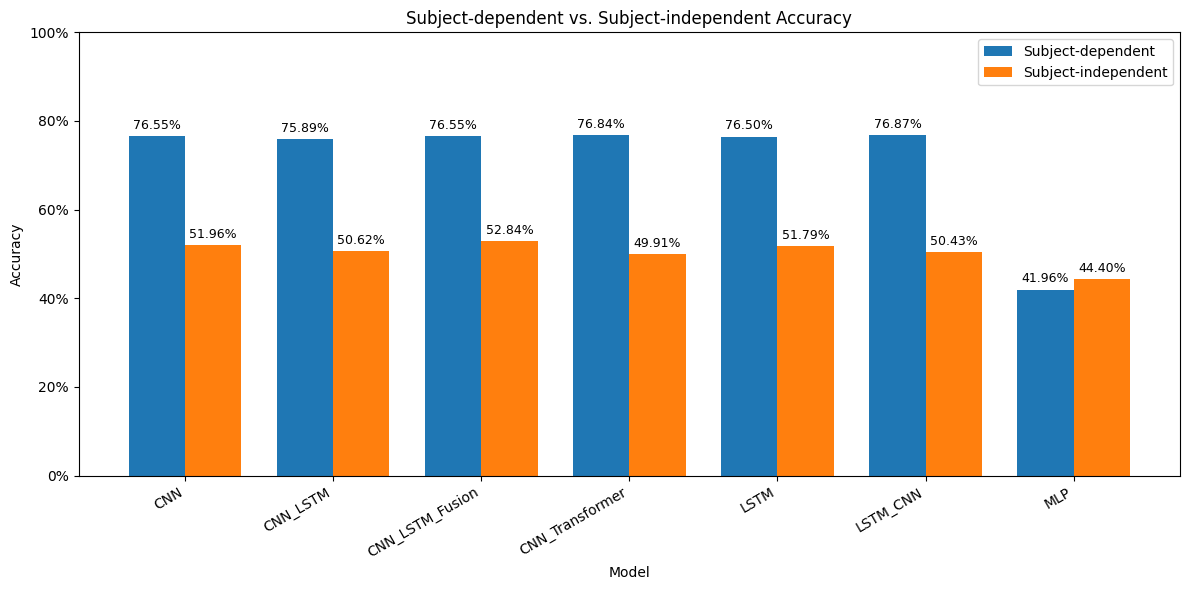

Saved figure to: ../results/dependent_vs_independent_accuracy.png


,model,dependent_accuracy,dependent_macro_f1,dependent_balanced_accuracy,independent_accuracy,independent_macro_f1,independent_balanced_accuracy,accuracy_change,accuracy_drop,macro_f1_change,balanced_accuracy_change
0,CNN,0.765483,0.763954,0.764543,0.519553,0.498340,0.502034,-0.245930,0.245930,-0.265614,-0.262509
1,CNN_LSTM,0.758923,0.757939,0.758403,0.506152,0.492772,0.493999,-0.252772,0.252772,-0.265167,-0.264404
2,CNN_LSTM_Fusion,0.765483,0.763773,0.764479,0.528442,0.504472,0.509247,-0.237041,0.237041,-0.259302,-0.255232
3,CNN_Transformer,0.768377,0.767582,0.768684,0.499127,0.478817,0.482222,-0.269251,0.269251,-0.288766,-0.286462
4,LSTM,0.765001,0.763626,0.765184,0.517905,0.509762,0.510278,-0.247096,0.247096,-0.253865,-0.254906
5,LSTM_CNN,0.768667,0.767560,0.768151,0.504268,0.480028,0.485203,-0.264399,0.264399,-0.287531,-0.282948
6,MLP,0.419641,0.380435,0.395762,0.443989,0.392918,0.416505,0.024348,-0.024348,0.012483,0.020743


In [31]:
compare_studies(dependent["pooled_metrics"], independent["pooled_metrics"], CSV_OUTPUT_PATH)